# Analyse des seuils par arbre de décision — terrainSA

Ce notebook utilise le fichier `dataset_metamodel.csv` produit par le notebook de simulation `batch_simulations_smt_terrainSA.ipynb`.

Il ne reconstruit pas les données depuis les logs MAELIA : les seuils doivent être calculés à partir de la matrice `xt` originale fusionnée aux sorties GAMA par le notebook de simulation.

L'objectif est différent : au lieu de quantifier uniquement l'importance globale des paramètres, on cherche des **valeurs seuils** et des **combinaisons locales de règles** qui séparent des régimes de réponse.

## Principe

Un `DecisionTreeRegressor` est entraîné pour chaque sortie (`N_lixi`, `dCorg`, `rdt`). L'arbre est volontairement contraint et sélectionné par validation croisée afin de rester interprétable. Les sorties produites sont :

- les performances de l'arbre sur un jeu de test ;
- les seuils utilisés par les noeuds internes ;
- les règles menant aux feuilles ;
- les moyennes observées dans chaque régime local ;
- une figure de l'arbre et une figure d'importance des paramètres.

Les résultats sont écrits dans `analysis/decision_tree_thresholds`.


In [21]:
# ============================================================
# 1. Imports et configuration
# ============================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA")
ANALYSIS_DIR = PROJECT_ROOT / "analysis"
OUTPUT_DIR = ANALYSIS_DIR / "decision_tree_thresholds"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Paramètres de sauvegarde des figures.
# Mettre SAVE_FIGURES=False pour afficher les figures sans les écrire sur disque.
SAVE_FIGURES = False
FIGURE_DPI = 180
SAVED_FIGURES = []

DATASET_CANDIDATES = [
    Path("/tmp/maelia_smt_terrainSA_xml/dataset_metamodel.csv"),
    PROJECT_ROOT / "data" / "dataset_metamodel_terrainSA.csv",
    ANALYSIS_DIR / "dataset_metamodel_terrainSA.csv",
    ANALYSIS_DIR / "dataset_metamodel.csv",
]

OUTPUT_COLS = ["N_lixi", "dCorg", "rdt"]

RANDOM_SEED = 42
TEST_SIZE = 0.25
CV_FOLDS = 5

# L'arbre est volontairement peu profond pour favoriser des seuils lisibles.
MAX_DEPTH_CANDIDATES = [2, 3, 4, 5]
CCP_ALPHA_CANDIDATES = [0.0, 1e-5, 1e-4, 1e-3]
PLOT_MAX_DEPTH = 4
TOP_SPLITS_TO_DISPLAY = 15
TOP_LEAVES_TO_DISPLAY = 12


In [22]:
# ============================================================
# 2. Chargement du dataset terrainSA
# ============================================================

DATASET_PATH = None
for candidate in DATASET_CANDIDATES:
    if candidate.exists():
        DATASET_PATH = candidate
        break

if DATASET_PATH is None:
    print("Aucun dataset terrainSA trouvé. Chemins testés :")
    for candidate in DATASET_CANDIDATES:
        print(" -", candidate)
    raise FileNotFoundError(
        "Exécuter d'abord le notebook de simulation terrainSA jusqu'à l'export "
        "de dataset_metamodel.csv, ou placer le fichier dans analysis/."
    )

df_raw = pd.read_csv(DATASET_PATH)
print("Dataset chargé :", DATASET_PATH)
print("Dimensions :", df_raw.shape)
display(df_raw.head())

missing_outputs = [col for col in OUTPUT_COLS if col not in df_raw.columns]
if missing_outputs:
    raise ValueError(f"Sorties absentes du dataset : {missing_outputs}")


Dataset chargé : /tmp/maelia_smt_terrainSA_xml/dataset_metamodel.csv
Dimensions : (10000, 33)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_23,feat_24,feat_25,Milieu (Climat),Milieu (Sol),N_lixi,dCorg,rdt,point_idx,parcelle
0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,55.000000,55.000000,55.000000,0,0,1.818,-270.588,4.725,0,beauce_5_sa_000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.000000,0,0,3.316,-232.936,4.465,1,beauce_5_sa_001
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.000000,0,0,2.870,-218.532,4.470,2,beauce_5_sa_002
3,3.0,1.0,0.0,2.0,0.0,2.0,1.0,1.0,1.0,1.0,...,94.621472,89.058881,11.224292,0,0,2.024,-190.614,4.595,3,beauce_5_sa_003
4,3.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,1.0,2.0,...,76.992364,86.894264,83.190509,0,0,3.114,-192.272,4.475,4,beauce_5_sa_004


In [23]:
# ============================================================
# 3. Reconstruction des paramètres agricoles
# ============================================================

# Ordre réel des colonnes feat_0...feat_25 après correction SMT/ADSG.
AGRI_FEATURES = ['n_ferti', 'has_prepa', 'nb_prepa', 'prepa_1', 'nb_f1', 'type_f1_1', 'nb_f2', 'type_f2_1', 'nb_f3', 'type_f3_1', 'prepa_2', 'type_f1_2', 'type_f2_2', 'type_f3_2', 'Date_Semis', 'Delta_PREPA_Semis', 'Date_F1', 'Date_F2', 'Date_F3', 'Date_Recolte', 'Dose_F1_1', 'Dose_F1_2', 'Dose_F2_1', 'Dose_F2_2', 'Dose_F3_1', 'Dose_F3_2']

AGRI_CATEGORICAL = ['n_ferti', 'has_prepa', 'nb_prepa', 'prepa_1', 'nb_f1', 'type_f1_1', 'nb_f2', 'type_f2_1', 'nb_f3', 'type_f3_1', 'prepa_2', 'type_f1_2', 'type_f2_2', 'type_f3_2']
AGRI_CONTINUOUS = [c for c in AGRI_FEATURES if c not in AGRI_CATEGORICAL]

feat_cols = [f"feat_{i}" for i in range(26)]
if all(col in df_raw.columns for col in feat_cols):
    X_params = df_raw[feat_cols].copy()
    X_params.columns = AGRI_FEATURES
elif df_raw.shape[1] >= 26:
    X_params = df_raw.iloc[:, :26].copy()
    X_params.columns = AGRI_FEATURES
else:
    raise ValueError("Le dataset doit contenir 26 colonnes de paramètres agricoles.")

df = pd.concat([X_params, df_raw[OUTPUT_COLS]], axis=1)

if "point_idx" in df_raw.columns:
    df["point_idx"] = df_raw["point_idx"]
if "parcelle" in df_raw.columns:
    df["parcelle"] = df_raw["parcelle"]

for col in ["Milieu (Climat)", "Milieu (Sol)", "zone", "sol_type", "zone_meteo"]:
    if col in df_raw.columns:
        df[col] = df_raw[col]

print("Paramètres agricoles :", len(AGRI_FEATURES))
print("Paramètres continus :", AGRI_CONTINUOUS)
print("Sorties :", OUTPUT_COLS)
display(df[AGRI_FEATURES + OUTPUT_COLS].head())


Paramètres agricoles : 26
Paramètres continus : ['Date_Semis', 'Delta_PREPA_Semis', 'Date_F1', 'Date_F2', 'Date_F3', 'Date_Recolte', 'Dose_F1_1', 'Dose_F1_2', 'Dose_F2_1', 'Dose_F2_2', 'Dose_F3_1', 'Dose_F3_2']
Sorties : ['N_lixi', 'dCorg', 'rdt']


,n_ferti,has_prepa,nb_prepa,prepa_1,nb_f1,type_f1_1,nb_f2,type_f2_1,nb_f3,type_f3_1,...,Date_Recolte,Dose_F1_1,Dose_F1_2,Dose_F2_1,Dose_F2_2,Dose_F3_1,Dose_F3_2,N_lixi,dCorg,rdt
0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,364.051227,38.319071,54.046022,77.120136,55.000000,55.000000,55.000000,1.818,-270.588,4.725
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,376.430508,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,3.316,-232.936,4.465
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,353.681635,55.000000,55.000000,55.000000,55.000000,55.000000,55.000000,2.870,-218.532,4.470
3,3.0,1.0,0.0,2.0,0.0,2.0,1.0,1.0,1.0,1.0,...,324.112423,32.924074,55.000000,21.918904,94.621472,89.058881,11.224292,2.024,-190.614,4.595
4,3.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,1.0,2.0,...,348.435468,90.048497,56.471329,57.513416,76.992364,86.894264,83.190509,3.114,-192.272,4.475


## Préparation des variables

Les variables continues sont utilisées directement : les seuils produits par l'arbre sont donc des valeurs numériques interprétables.

Les variables catégorielles sont encodées en indicatrices. Dans ce cas, un seuil proche de `0.5` se lit comme une règle d'appartenance : par exemple `type_f1_2 == X` ou `type_f1_2 != X`. Cela évite d'interpréter artificiellement un code de catégorie comme une grandeur ordonnée.

In [24]:
# ============================================================
# 4. Préprocesseur et fonctions d'interprétation
# ============================================================

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor():
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="inactif")),
        ("onehot", make_one_hot_encoder()),
    ])
    continuous_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    return ColumnTransformer(
        transformers=[
            ("cat", categorical_pipe, AGRI_CATEGORICAL),
            ("cont", continuous_pipe, AGRI_CONTINUOUS),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def transformed_feature_names(preprocessor):
    try:
        return list(preprocessor.get_feature_names_out())
    except Exception:
        names = []
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        for feature, cats in zip(AGRI_CATEGORICAL, ohe.categories_):
            names.extend([f"cat__{feature}_{cat}" for cat in cats])
        names.extend([f"cont__{feature}" for feature in AGRI_CONTINUOUS])
        return names


def parse_transformed_feature(name):
    if name.startswith("cont__"):
        raw = name.replace("cont__", "", 1)
        return raw, "continuous", None

    if name.startswith("cat__"):
        rest = name.replace("cat__", "", 1)
        for feature in sorted(AGRI_CATEGORICAL, key=len, reverse=True):
            prefix = feature + "_"
            if rest.startswith(prefix):
                return feature, "categorical", rest[len(prefix):]

    return name, "unknown", None


def format_split_rule(feature_name, threshold, direction):
    raw, kind, category = parse_transformed_feature(feature_name)
    if kind == "categorical" and abs(threshold - 0.5) < 0.51:
        return f"{raw} != {category}" if direction == "left" else f"{raw} == {category}"

    op = "<=" if direction == "left" else ">"
    return f"{raw} {op} {threshold:.4g}"


def raw_feature_from_transformed(name):
    raw, _, _ = parse_transformed_feature(name)
    return raw


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def save_current_figure(filename, title, target=None, kind=None):
    """Save the active matplotlib figure and register it for README reuse."""
    path = OUTPUT_DIR / filename
    if SAVE_FIGURES:
        plt.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        try:
            rel_path = path.relative_to(PROJECT_ROOT)
        except ValueError:
            rel_path = path
        SAVED_FIGURES.append({
            "figure": str(rel_path),
            "title": title,
            "sortie": target,
            "type": kind,
        })
        print("Figure écrite :", rel_path)
    else:
        print("SAVE_FIGURES=False : figure non sauvegardée.")
    return path

In [25]:
# ============================================================
# 5. Extraction des seuils et des régimes locaux
# ============================================================

def extract_splits(tree, feature_names):
    rows = []
    t = tree.tree_
    for node in range(t.node_count):
        left = t.children_left[node]
        right = t.children_right[node]
        if left == right:
            continue

        feature_name = feature_names[t.feature[node]]
        raw_feature, kind, category = parse_transformed_feature(feature_name)
        n_node = int(t.n_node_samples[node])
        n_left = int(t.n_node_samples[left])
        n_right = int(t.n_node_samples[right])
        value_node = float(t.value[node].ravel()[0])
        value_left = float(t.value[left].ravel()[0])
        value_right = float(t.value[right].ravel()[0])
        impurity_decrease = (
            t.impurity[node]
            - (n_left / n_node) * t.impurity[left]
            - (n_right / n_node) * t.impurity[right]
        )

        rows.append({
            "node": node,
            "raw_feature": raw_feature,
            "kind": kind,
            "category": category,
            "threshold": float(t.threshold[node]),
            "left_rule": format_split_rule(feature_name, t.threshold[node], "left"),
            "right_rule": format_split_rule(feature_name, t.threshold[node], "right"),
            "n_node_train": n_node,
            "n_left_train": n_left,
            "n_right_train": n_right,
            "mean_node_train": value_node,
            "mean_left_train": value_left,
            "mean_right_train": value_right,
            "delta_right_minus_left": value_right - value_left,
            "impurity_decrease": float(impurity_decrease),
        })

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("impurity_decrease", ascending=False)


def collect_leaf_rules(tree, feature_names):
    t = tree.tree_
    leaf_rules = {}

    def visit(node, rules):
        left = t.children_left[node]
        right = t.children_right[node]
        if left == right:
            leaf_rules[node] = rules
            return

        feature_name = feature_names[t.feature[node]]
        threshold = t.threshold[node]
        visit(left, rules + [format_split_rule(feature_name, threshold, "left")])
        visit(right, rules + [format_split_rule(feature_name, threshold, "right")])

    visit(0, [])
    return leaf_rules


def extract_leaf_summary(pipe, X, y, feature_names):
    preprocess = pipe.named_steps["preprocess"]
    tree = pipe.named_steps["tree"]
    X_trans = preprocess.transform(X)
    leaf_ids = tree.apply(X_trans)
    leaf_rules = collect_leaf_rules(tree, feature_names)

    data = pd.DataFrame({"leaf_id": leaf_ids, "y": y.to_numpy()})
    summary = (
        data.groupby("leaf_id")
        .agg(n=("y", "size"), mean=("y", "mean"), std=("y", "std"), min=("y", "min"), max=("y", "max"))
        .reset_index()
    )
    summary["rules"] = summary["leaf_id"].map(lambda leaf: " ET ".join(leaf_rules.get(int(leaf), [])))
    return summary.sort_values("mean")


def aggregate_raw_importance(tree, feature_names):
    rows = []
    for transformed, importance in zip(feature_names, tree.feature_importances_):
        rows.append({
            "raw_feature": raw_feature_from_transformed(transformed),
            "transformed_feature": transformed,
            "importance": float(importance),
        })
    detail = pd.DataFrame(rows)
    agg = (
        detail.groupby("raw_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    return agg, detail

## Entraînement des arbres

Pour chaque sortie, le notebook cherche automatiquement une complexité raisonnable de l'arbre par validation croisée. Le score affiché sur le jeu de test (`Q2_test`) permet de vérifier si l'arbre reste suffisamment fidèle pour que ses seuils soient utiles.

Un arbre peu profond peut être moins précis qu'ExtraTrees ou XGBoost, mais il est beaucoup plus lisible : son intérêt est l'identification de seuils, pas la prédiction maximale.


Sortie : N_lixi


,sortie,best_params,CV_R2_mean,R2_train,Q2_test,MAE_test,RMSE_test,n_train,n_test
0,N_lixi,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 5,...",0.887975,0.899798,0.887238,0.108896,0.149711,7500,2500


Principaux seuils :


,sortie,node,raw_feature,kind,category,threshold,left_rule,right_rule,n_node_train,n_left_train,n_right_train,mean_node_train,mean_left_train,mean_right_train,delta_right_minus_left,impurity_decrease
10,N_lixi,18,Date_Semis,continuous,NaN,52.767551,Date_Semis <= 52.77,Date_Semis > 52.77,166,47,119,2.452723,1.976128,2.640958,0.664830,0.089712
3,N_lixi,3,Date_Semis,continuous,NaN,56.323318,Date_Semis <= 56.32,Date_Semis > 56.32,472,199,273,2.065360,1.719397,2.317546,0.598149,0.087247
0,N_lixi,0,Date_Semis,continuous,NaN,73.232361,Date_Semis <= 73.23,Date_Semis > 73.23,7500,3477,4023,2.824356,2.533945,3.075353,0.541408,0.072892
24,N_lixi,47,Date_Semis,continuous,NaN,81.089573,Date_Semis <= 81.09,Date_Semis > 81.09,472,109,363,3.479314,3.068202,3.602760,0.534558,0.050750
15,N_lixi,30,Delta_PREPA_Semis,continuous,NaN,-24.240369,Delta_PREPA_Semis <= -24.24,Delta_PREPA_Semis > -24.24,4023,1034,2989,3.075353,2.715718,3.199763,0.484046,0.044742
9,N_lixi,17,Delta_PREPA_Semis,continuous,NaN,-27.780742,Delta_PREPA_Semis <= -27.78,Delta_PREPA_Semis > -27.78,822,166,656,2.868151,2.452723,2.973274,0.520551,0.043671
1,N_lixi,1,Date_Recolte,continuous,NaN,369.658630,Date_Recolte <= 369.7,Date_Recolte > 369.7,3477,2655,822,2.533945,2.430473,2.868151,0.437678,0.034581
2,N_lixi,2,Delta_PREPA_Semis,continuous,NaN,-29.394433,Delta_PREPA_Semis <= -29.39,Delta_PREPA_Semis > -29.39,2655,472,2183,2.430473,2.065360,2.509416,0.444056,0.028823
20,N_lixi,39,Date_Recolte,continuous,NaN,331.498291,Date_Recolte <= 331.5,Date_Recolte > 331.5,483,74,409,2.858282,3.233054,2.790474,-0.442580,0.025412
12,N_lixi,23,Date_Recolte,continuous,NaN,375.574905,Date_Recolte <= 375.6,Date_Recolte > 375.6,656,257,399,2.973274,2.787518,3.092922,0.305405,0.022225


Régimes locaux les plus contrastés :


,sortie,leaf_id,n,mean,std,min,max,rules
0,N_lixi,5,139,1.571209,0.185279,1.206,2.132,Date_Semis <= 73.23 ET Date_Recolte <= 369.7 E...
1,N_lixi,6,141,1.855390,0.254727,1.440,2.492,Date_Semis <= 73.23 ET Date_Recolte <= 369.7 E...
8,N_lixi,19,62,2.035419,0.392340,1.384,3.224,Date_Semis <= 73.23 ET Date_Recolte > 369.7 ET...
4,N_lixi,12,387,2.161876,0.116702,1.544,2.440,Date_Semis <= 73.23 ET Date_Recolte <= 369.7 E...
2,N_lixi,8,136,2.198015,0.230455,1.728,2.636,Date_Semis <= 73.23 ET Date_Recolte <= 369.7 E...
3,N_lixi,9,220,2.412245,0.074657,2.036,2.586,Date_Semis <= 73.23 ET Date_Recolte <= 369.7 E...
13,N_lixi,28,321,3.155352,0.084125,2.994,3.398,Date_Semis <= 73.23 ET Date_Recolte > 369.7 ET...
24,N_lixi,50,74,3.198757,0.163937,2.858,3.536,Date_Semis > 73.23 ET Delta_PREPA_Semis > -24....
30,N_lixi,60,1870,3.254548,0.108038,3.050,3.644,Date_Semis > 73.23 ET Delta_PREPA_Semis > -24....
20,N_lixi,42,50,3.335360,0.103641,3.112,3.518,Date_Semis > 73.23 ET Delta_PREPA_Semis <= -24...


SAVE_FIGURES=False : figure non sauvegardée.


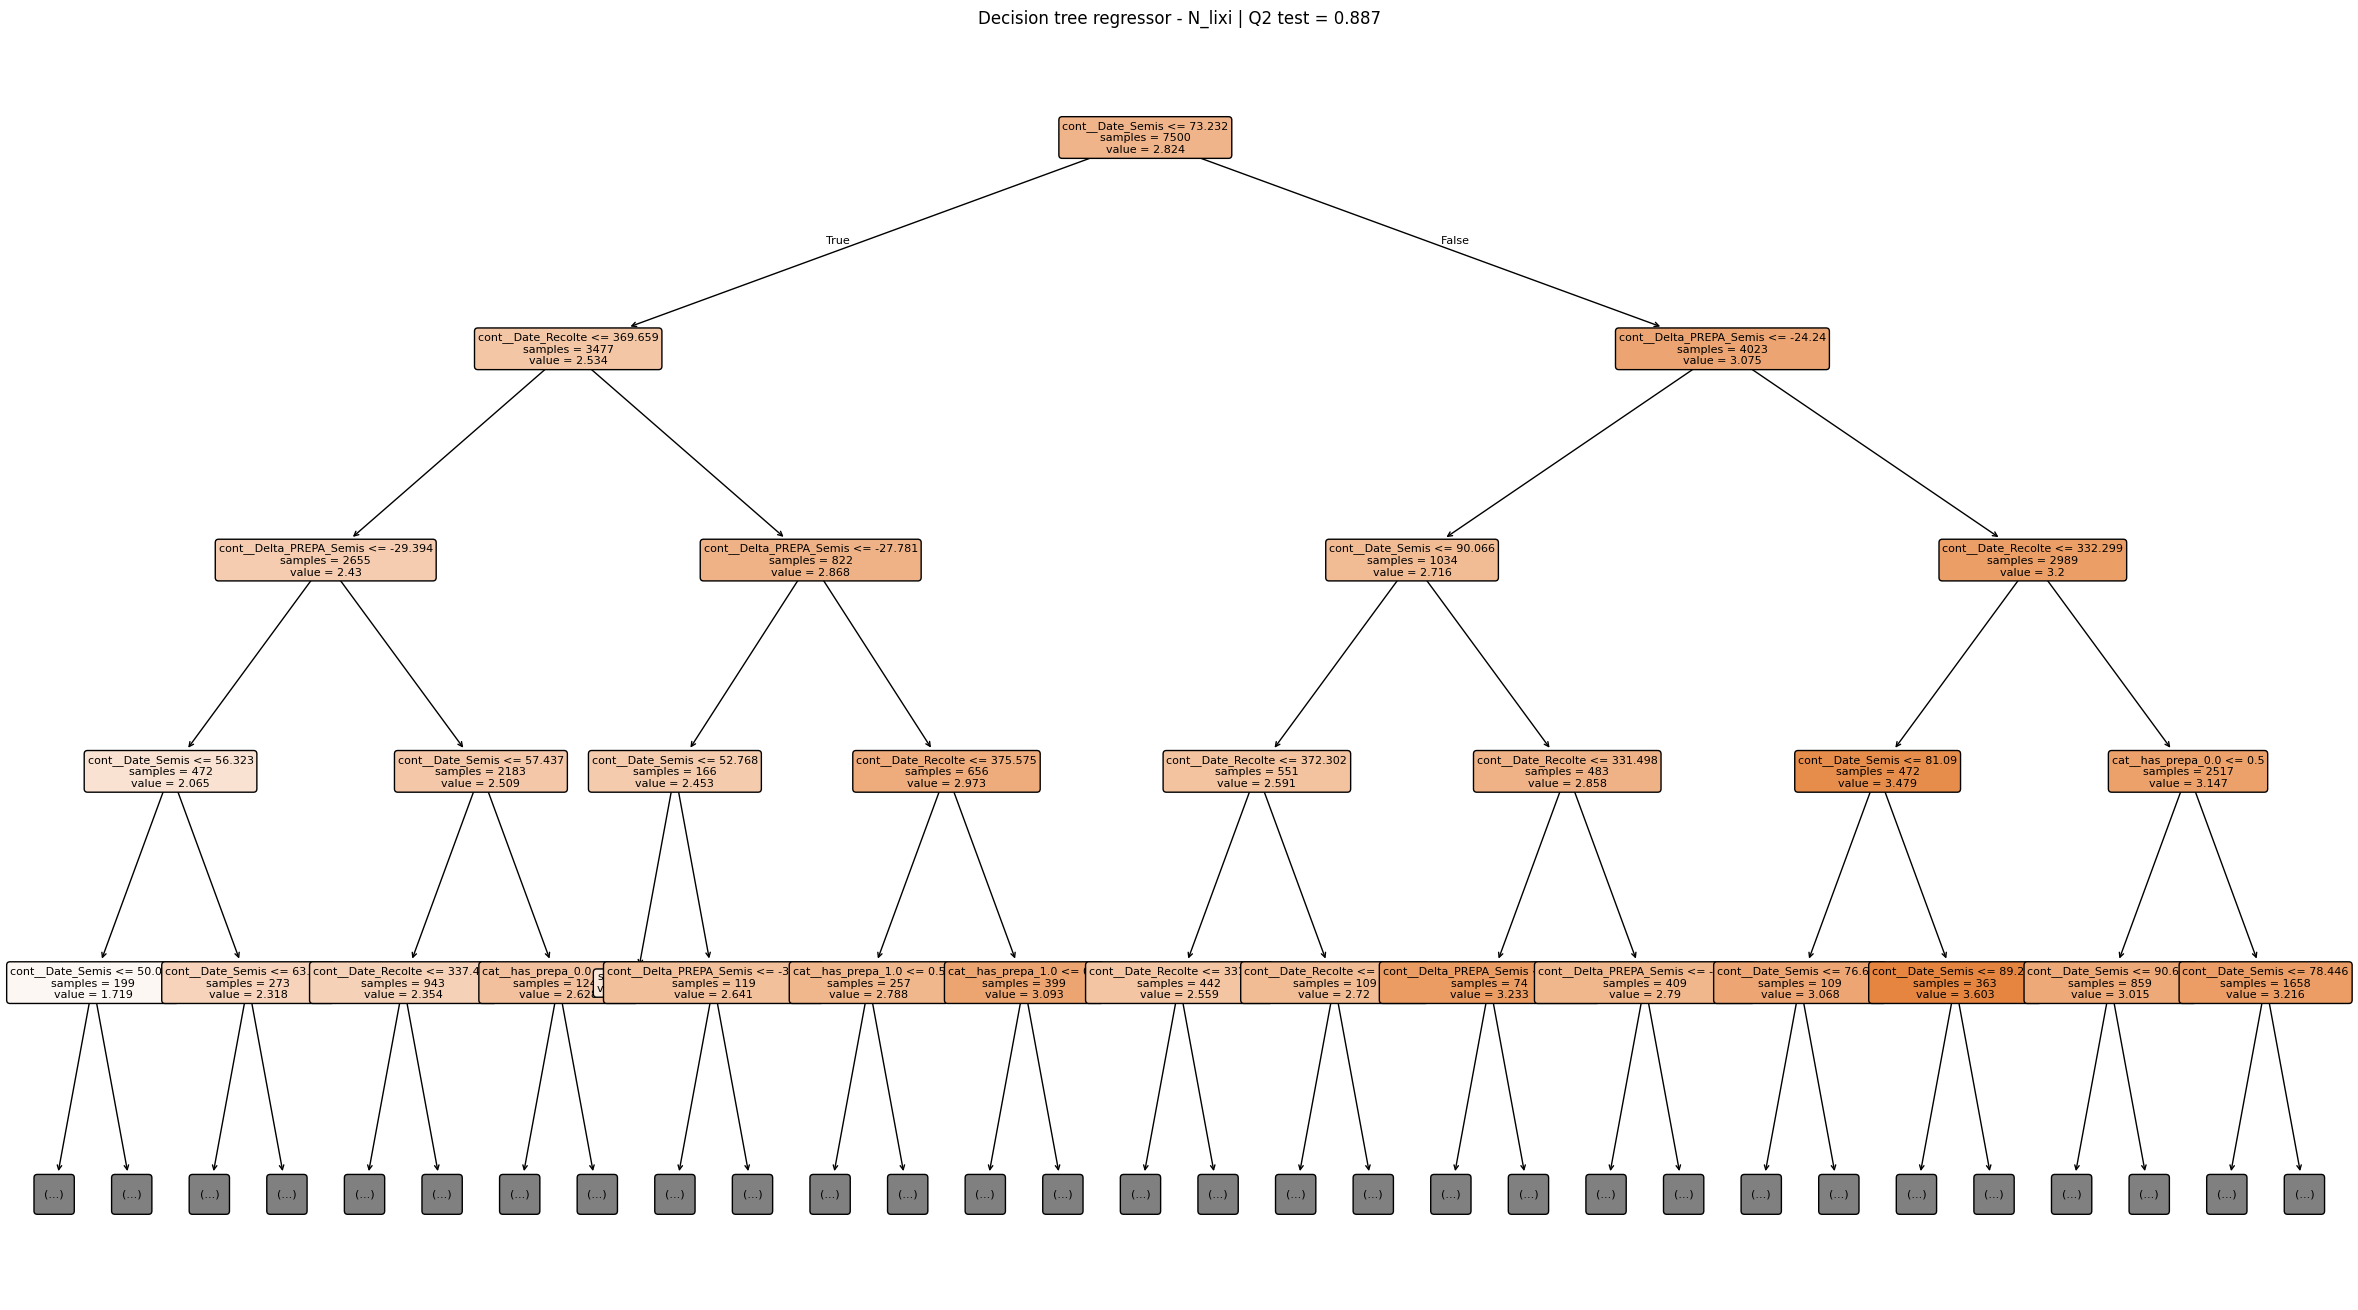

SAVE_FIGURES=False : figure non sauvegardée.


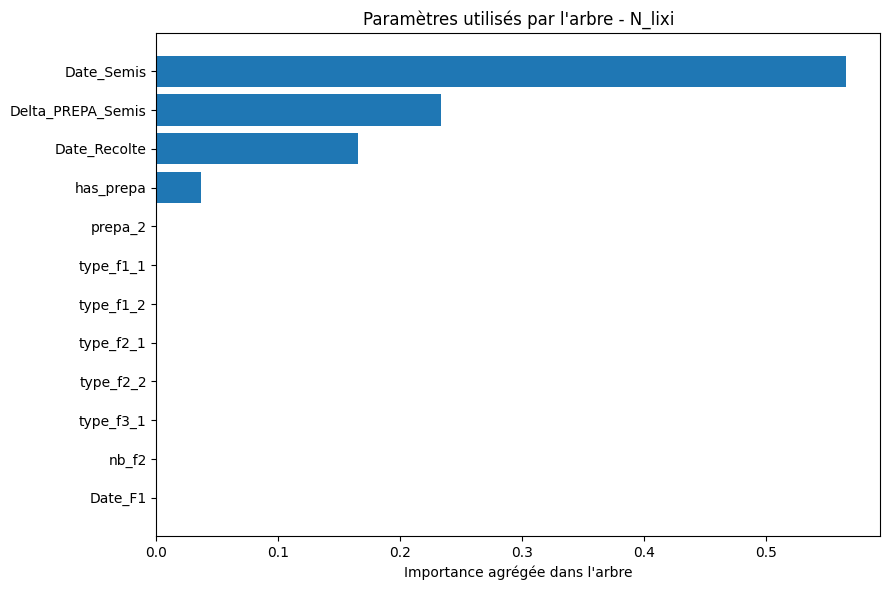


Sortie : dCorg


,sortie,best_params,CV_R2_mean,R2_train,Q2_test,MAE_test,RMSE_test,n_train,n_test
0,dCorg,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 5,...",0.966329,0.969272,0.966177,5.407388,6.61801,7500,2500


Principaux seuils :


,sortie,node,raw_feature,kind,category,threshold,left_rule,right_rule,n_node_train,n_left_train,n_right_train,mean_node_train,mean_left_train,mean_right_train,delta_right_minus_left,impurity_decrease
0,dCorg,0,Date_Recolte,continuous,None,352.623795,Date_Recolte <= 352.6,Date_Recolte > 352.6,7500,3625,3875,-215.702394,-189.344494,-240.359785,-51.015291,649.917058
16,dCorg,32,Date_Semis,continuous,None,64.689243,Date_Semis <= 64.69,Date_Semis > 64.69,3875,1291,2584,-240.359785,-266.681997,-227.208866,39.473131,346.161278
1,dCorg,1,Date_Semis,continuous,None,64.980171,Date_Semis <= 64.98,Date_Semis > 64.98,3625,1173,2452,-189.344494,-212.324297,-178.351301,33.972996,252.621404
17,dCorg,33,Date_Recolte,continuous,None,367.503998,Date_Recolte <= 367.5,Date_Recolte > 367.5,1291,597,694,-266.681997,-250.938214,-280.225280,-29.287065,213.222496
2,dCorg,2,Date_Recolte,continuous,None,336.182816,Date_Recolte <= 336.2,Date_Recolte > 336.2,1173,484,689,-212.324297,-194.949979,-224.529187,-29.579208,212.051642
24,dCorg,48,Date_Recolte,continuous,None,369.204514,Date_Recolte <= 369.2,Date_Recolte > 369.2,2584,1380,1204,-227.208866,-214.256143,-242.055010,-27.798866,192.297984
9,dCorg,17,Date_Recolte,continuous,None,337.014374,Date_Recolte <= 337,Date_Recolte > 337,2452,1171,1281,-178.351301,-165.395033,-190.195009,-24.799975,153.450246
28,dCorg,56,Date_Semis,continuous,None,84.671432,Date_Semis <= 84.67,Date_Semis > 84.67,1204,585,619,-242.055010,-252.236588,-232.432679,19.803910,97.970519
25,dCorg,49,Date_Semis,continuous,None,82.796471,Date_Semis <= 82.8,Date_Semis > 82.8,1380,633,747,-214.256143,-224.771735,-205.345341,19.426393,93.702352
21,dCorg,41,Date_Semis,continuous,None,54.140379,Date_Semis <= 54.14,Date_Semis > 54.14,694,318,376,-280.225280,-290.337843,-271.672633,18.665210,86.489179


Régimes locaux les plus contrastés :


,sortie,leaf_id,n,mean,std,min,max,rules
21,dCorg,44,195,-298.164697,7.782055,-314.920,-274.550,Date_Recolte > 352.6 ET Date_Semis <= 64.69 ET...
20,dCorg,43,228,-284.605158,7.135130,-301.500,-269.350,Date_Recolte > 352.6 ET Date_Semis <= 64.69 ET...
23,dCorg,47,248,-278.734540,6.626541,-294.506,-263.640,Date_Recolte > 352.6 ET Date_Semis <= 64.69 ET...
17,dCorg,37,212,-266.378453,7.031531,-283.728,-251.488,Date_Recolte > 352.6 ET Date_Semis <= 64.69 ET...
22,dCorg,46,239,-264.533464,6.768726,-280.088,-248.748,Date_Recolte > 352.6 ET Date_Semis <= 64.69 ET...
29,dCorg,59,462,-257.588615,7.789125,-278.148,-241.166,Date_Recolte > 352.6 ET Date_Semis > 64.69 ET ...
2,dCorg,8,186,-182.191796,5.614448,-198.476,-170.204,Date_Recolte <= 352.6 ET Date_Semis <= 64.98 E...
9,dCorg,21,302,-180.131444,5.891852,-199.150,-166.688,Date_Recolte <= 352.6 ET Date_Semis > 64.98 ET...
14,dCorg,30,560,-176.897596,6.368388,-192.246,-161.200,Date_Recolte <= 352.6 ET Date_Semis > 64.98 ET...
8,dCorg,20,462,-168.627450,5.363076,-183.002,-155.152,Date_Recolte <= 352.6 ET Date_Semis > 64.98 ET...


SAVE_FIGURES=False : figure non sauvegardée.


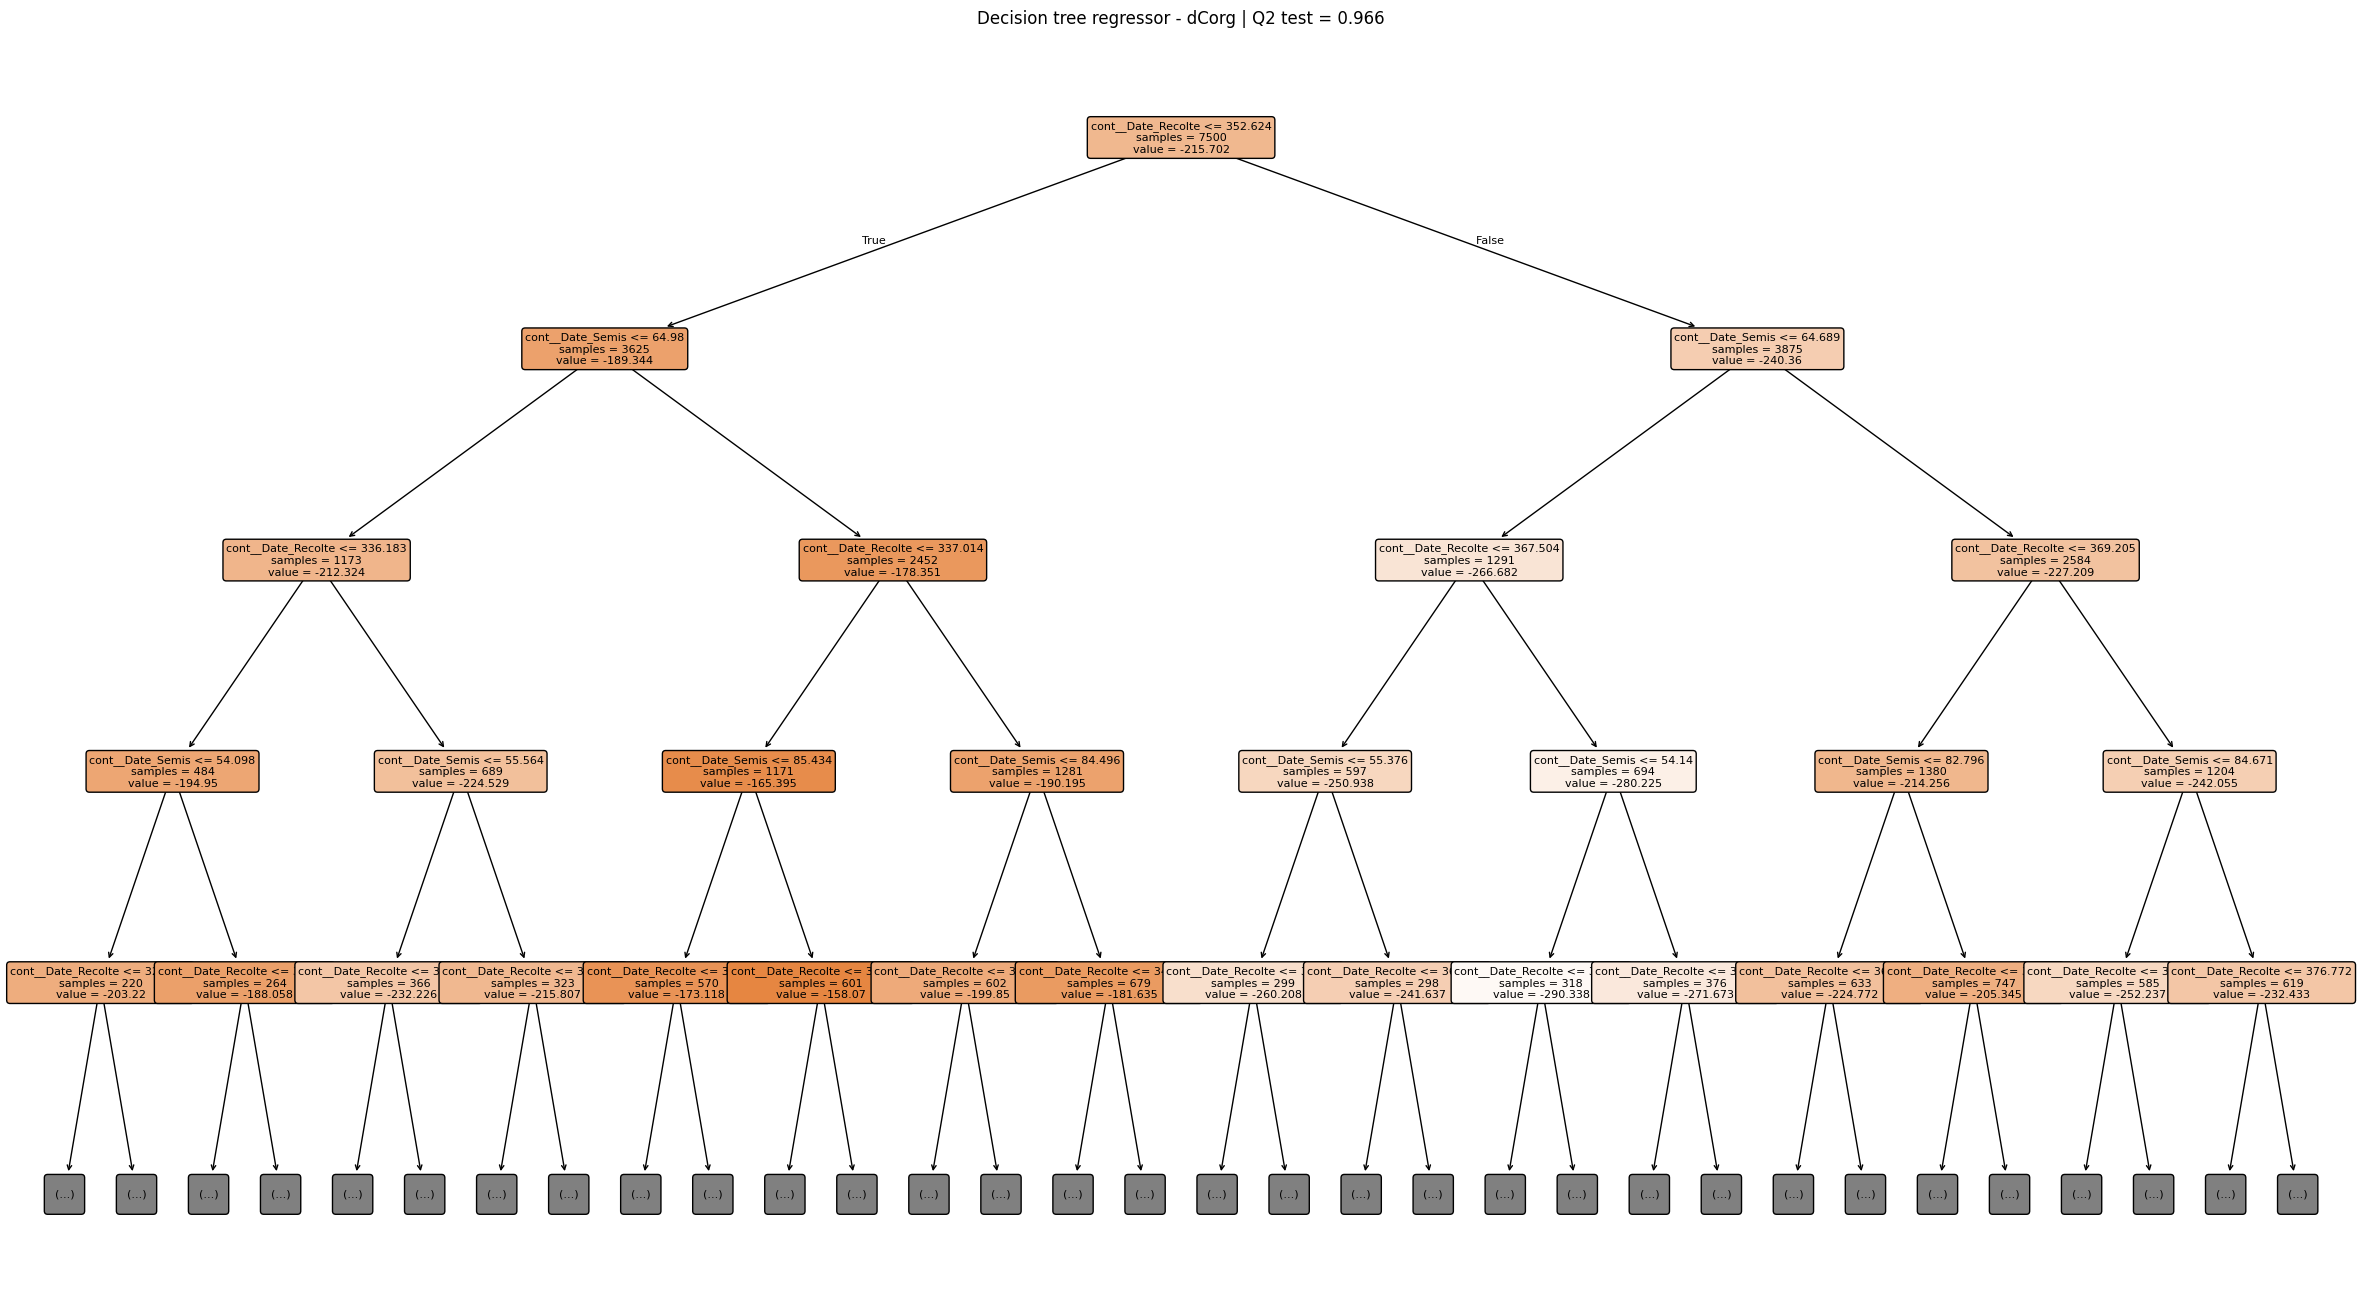

SAVE_FIGURES=False : figure non sauvegardée.


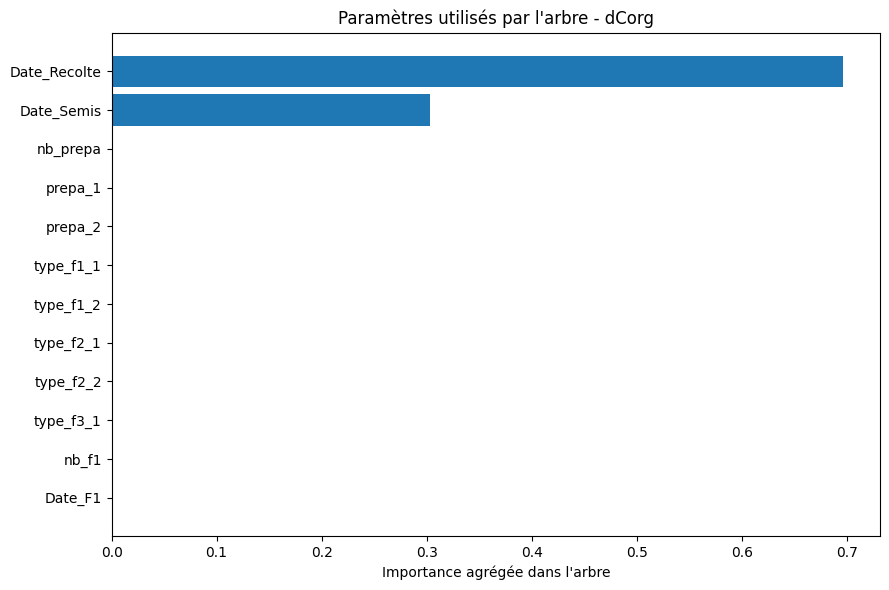


Sortie : rdt


,sortie,best_params,CV_R2_mean,R2_train,Q2_test,MAE_test,RMSE_test,n_train,n_test
0,rdt,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 5,...",0.87582,0.898969,0.878934,0.03485,0.047316,7500,2500


Principaux seuils :


,sortie,node,raw_feature,kind,category,threshold,left_rule,right_rule,n_node_train,n_left_train,n_right_train,mean_node_train,mean_left_train,mean_right_train,delta_right_minus_left,impurity_decrease
2,rdt,2,Date_Semis,continuous,NaN,77.010677,Date_Semis <= 77.01,Date_Semis > 77.01,350,165,185,4.496300,4.665636,4.345270,-0.320366,0.025575
15,rdt,29,Date_Semis,continuous,NaN,70.481434,Date_Semis <= 70.48,Date_Semis > 70.48,811,317,494,4.311011,4.502019,4.188441,-0.313578,0.023412
24,rdt,46,Date_Semis,continuous,NaN,77.637619,Date_Semis <= 77.64,Date_Semis > 77.64,482,261,221,4.403423,4.494157,4.296267,-0.197890,0.009723
0,rdt,0,Delta_PREPA_Semis,continuous,NaN,-24.558951,Delta_PREPA_Semis <= -24.56,Delta_PREPA_Semis > -24.56,7500,1840,5660,4.494811,4.626223,4.452091,-0.174132,0.005614
5,rdt,8,Date_Semis,continuous,NaN,96.352436,Date_Semis <= 96.35,Date_Semis > 96.35,185,117,68,4.345270,4.401368,4.248750,-0.152618,0.005415
3,rdt,3,Date_Semis,continuous,NaN,64.833645,Date_Semis <= 64.83,Date_Semis > 64.83,165,101,64,4.665636,4.722079,4.576562,-0.145517,0.005028
19,rdt,37,Date_Semis,continuous,NaN,81.257427,Date_Semis <= 81.26,Date_Semis > 81.26,494,139,355,4.188441,4.293525,4.147296,-0.146229,0.004324
28,rdt,56,Date_Recolte,continuous,NaN,341.357697,Date_Recolte <= 341.4,Date_Recolte > 341.4,734,136,598,4.485668,4.353346,4.515761,0.162415,0.003982
1,rdt,1,Date_Recolte,continuous,NaN,335.138214,Date_Recolte <= 335.1,Date_Recolte > 335.1,1840,350,1490,4.626223,4.496300,4.656742,0.160442,0.003965
14,rdt,28,Date_Recolte,continuous,NaN,332.005386,Date_Recolte <= 332,Date_Recolte > 332,5660,811,4849,4.452091,4.311011,4.475687,0.164676,0.003329


Régimes locaux les plus contrastés :


,sortie,leaf_id,n,mean,std,min,max,rules
20,rdt,42,387,4.135891,0.042651,4.060,4.340,Delta_PREPA_Semis > -24.56 ET Date_Recolte <= ...
21,rdt,43,71,4.209648,0.044660,4.125,4.330,Delta_PREPA_Semis > -24.56 ET Date_Recolte <= ...
5,rdt,12,92,4.245652,0.074845,4.080,4.450,Delta_PREPA_Semis <= -24.56 ET Date_Recolte <=...
19,rdt,40,117,4.270214,0.065160,4.130,4.405,Delta_PREPA_Semis > -24.56 ET Date_Recolte <= ...
23,rdt,48,301,4.293439,0.068565,4.160,4.450,Delta_PREPA_Semis > -24.56 ET Date_Recolte > 3...
3,rdt,10,81,4.344136,0.077765,4.195,4.470,Delta_PREPA_Semis <= -24.56 ET Date_Recolte <=...
10,rdt,23,382,4.657291,0.035725,4.575,4.785,Delta_PREPA_Semis <= -24.56 ET Date_Recolte > ...
1,rdt,6,72,4.673542,0.048777,4.535,4.775,Delta_PREPA_Semis <= -24.56 ET Date_Recolte <=...
8,rdt,19,689,4.685631,0.043214,4.480,4.820,Delta_PREPA_Semis <= -24.56 ET Date_Recolte > ...
7,rdt,17,61,4.705902,0.067451,4.550,4.855,Delta_PREPA_Semis <= -24.56 ET Date_Recolte > ...


SAVE_FIGURES=False : figure non sauvegardée.


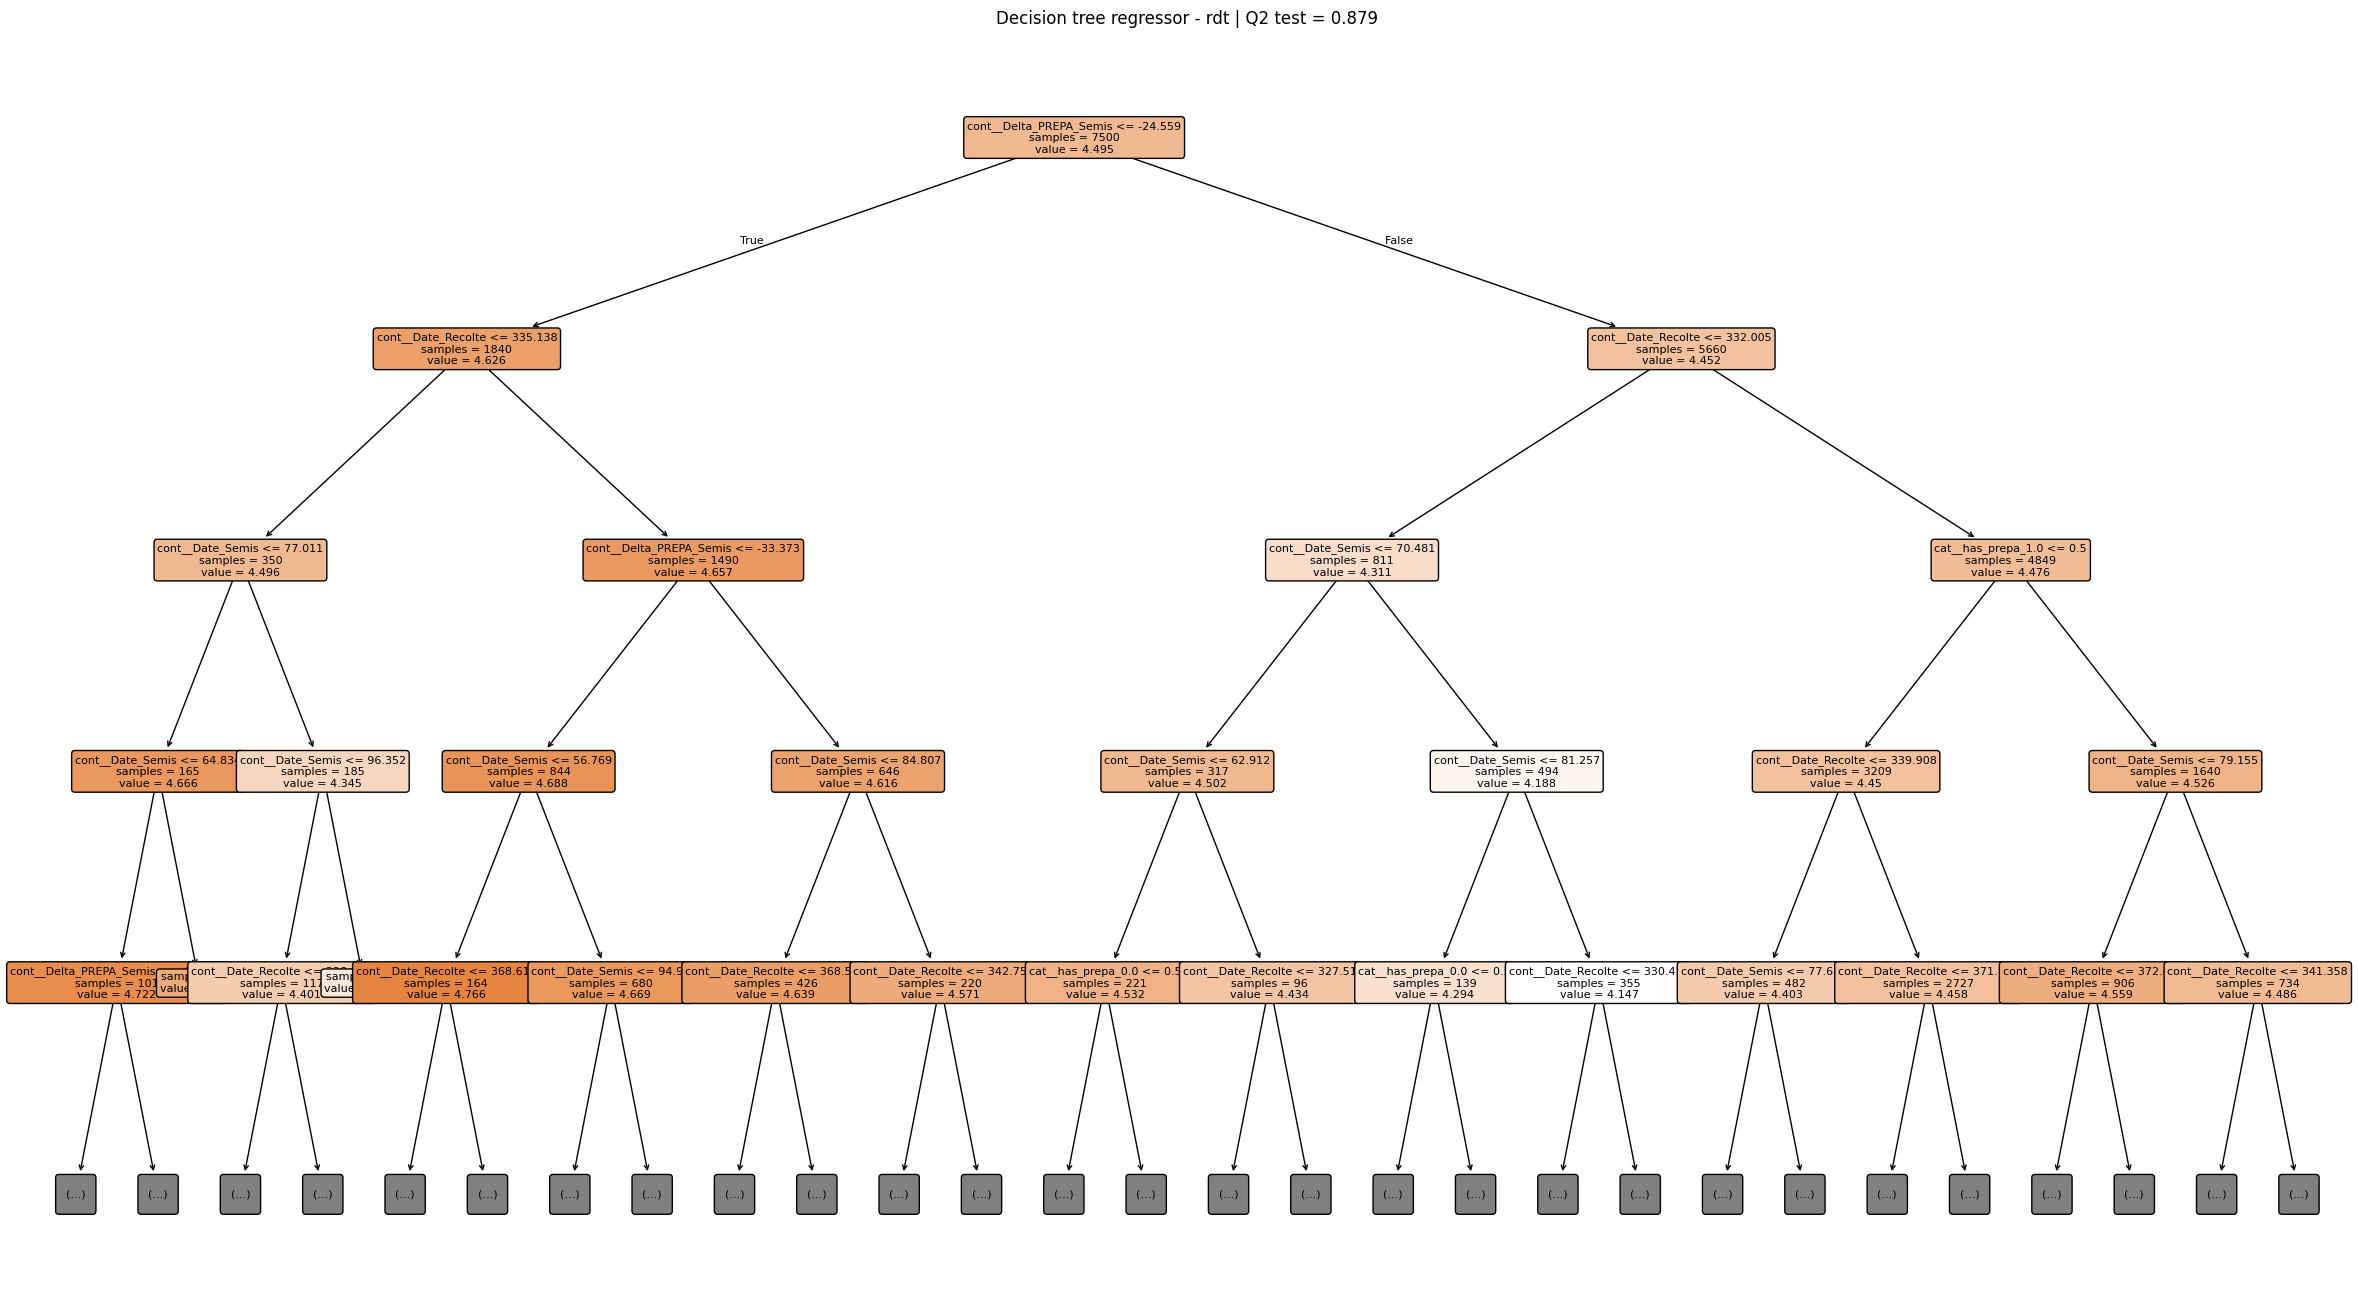

SAVE_FIGURES=False : figure non sauvegardée.


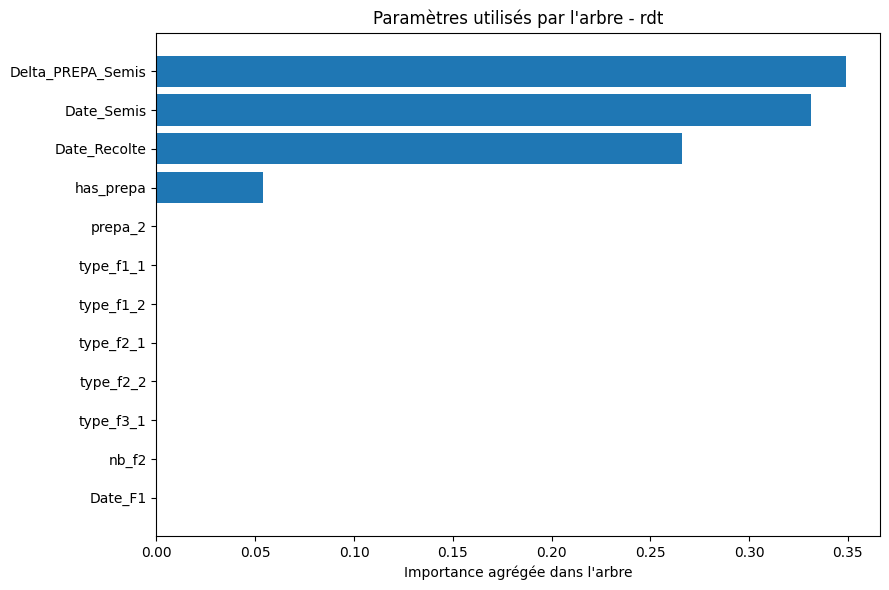


Résultats écrits dans : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/decision_tree_thresholds


,sortie,best_params,CV_R2_mean,R2_train,Q2_test,MAE_test,RMSE_test,n_train,n_test
0,N_lixi,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 5,...",0.887975,0.899798,0.887238,0.108896,0.149711,7500,2500
1,dCorg,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 5,...",0.966329,0.969272,0.966177,5.407388,6.618010,7500,2500
2,rdt,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 5,...",0.875820,0.898969,0.878934,0.034850,0.047316,7500,2500


In [26]:
# ============================================================
# 6. Entraînement des arbres de décision par sortie
# ============================================================

X = df[AGRI_FEATURES].copy()

# Les paramètres catégoriels sont codés numériquement dans le dataset SMT.
# On les convertit explicitement en chaînes pour que l'imputation "inactif"
# et le OneHotEncoder les traitent comme des modalités, pas comme des grandeurs.
for col in AGRI_CATEGORICAL:
    X[col] = X[col].astype("object").where(X[col].notna(), "inactif").astype(str)

for col in AGRI_CONTINUOUS:
    X[col] = pd.to_numeric(X[col], errors="coerce")

SAVED_FIGURES.clear()

metrics_rows = []
all_split_tables = []
all_leaf_tables = []
all_importance_tables = []
fitted_trees = {}

for target in OUTPUT_COLS:
    print("\n" + "=" * 80)
    print("Sortie :", target)
    print("=" * 80)

    y = df[target].astype(float)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
    )

    n_train = len(X_train)
    min_leaf_candidates = sorted({
        max(10, int(0.005 * n_train)),
        max(25, int(0.01 * n_train)),
        max(50, int(0.02 * n_train)),
        max(100, int(0.05 * n_train)),
    })

    pipe = Pipeline([
        ("preprocess", build_preprocessor()),
        ("tree", DecisionTreeRegressor(random_state=RANDOM_SEED)),
    ])

    param_grid = {
        "tree__max_depth": MAX_DEPTH_CANDIDATES,
        "tree__min_samples_leaf": min_leaf_candidates,
        "tree__ccp_alpha": CCP_ALPHA_CANDIDATES,
    }

    cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    best_pipe = grid.best_estimator_
    fitted_trees[target] = best_pipe

    y_pred_train = best_pipe.predict(X_train)
    y_pred_test = best_pipe.predict(X_test)

    metrics = {
        "sortie": target,
        "best_params": str(grid.best_params_),
        "CV_R2_mean": float(grid.best_score_),
        "R2_train": float(r2_score(y_train, y_pred_train)),
        "Q2_test": float(r2_score(y_test, y_pred_test)),
        "MAE_test": float(mean_absolute_error(y_test, y_pred_test)),
        "RMSE_test": rmse(y_test, y_pred_test),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
    }
    metrics_rows.append(metrics)
    display(pd.DataFrame([metrics]))

    preprocess = best_pipe.named_steps["preprocess"]
    tree = best_pipe.named_steps["tree"]
    feature_names = transformed_feature_names(preprocess)

    # Seuils de noeuds internes
    splits = extract_splits(tree, feature_names)
    if not splits.empty:
        splits.insert(0, "sortie", target)
        splits.to_csv(OUTPUT_DIR / f"decision_tree_splits_{target}.csv", index=False)
        all_split_tables.append(splits)
        print("Principaux seuils :")
        display(splits.head(TOP_SPLITS_TO_DISPLAY))

    # Régimes locaux / feuilles
    leaves = extract_leaf_summary(best_pipe, X, y, feature_names)
    leaves.insert(0, "sortie", target)
    leaves.to_csv(OUTPUT_DIR / f"decision_tree_leaf_regimes_{target}.csv", index=False)
    all_leaf_tables.append(leaves)
    print("Régimes locaux les plus contrastés :")
    display(pd.concat([leaves.head(6), leaves.tail(6)]).drop_duplicates())

    # Importance agrégée par paramètre d'origine
    raw_importance, importance_detail = aggregate_raw_importance(tree, feature_names)
    raw_importance.insert(0, "sortie", target)
    raw_importance.to_csv(OUTPUT_DIR / f"decision_tree_importance_{target}.csv", index=False)
    all_importance_tables.append(raw_importance)

    # Règles textuelles brutes
    rules_text = export_text(tree, feature_names=feature_names, decimals=4)
    (OUTPUT_DIR / f"decision_tree_rules_{target}.txt").write_text(rules_text, encoding="utf-8")

    # Figure de l'arbre
    fig_height = max(8, 2.2 * (tree.get_depth() + 1))
    plt.figure(figsize=(24, fig_height))
    plot_tree(
        tree,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        impurity=False,
        max_depth=PLOT_MAX_DEPTH,
        fontsize=8,
    )
    plt.title(f"Decision tree regressor - {target} | Q2 test = {metrics['Q2_test']:.3f}")
    plt.tight_layout()
    save_current_figure(f"decision_tree_{target}.png", f"Arbre de décision - {target}", target=target, kind="decision_tree")
    plt.show()

    # Figure d'importance
    top_imp = raw_importance.head(12).sort_values("importance", ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(top_imp["raw_feature"], top_imp["importance"])
    plt.xlabel("Importance agrégée dans l'arbre")
    plt.title(f"Paramètres utilisés par l'arbre - {target}")
    plt.tight_layout()
    save_current_figure(f"decision_tree_importance_{target}.png", f"Importance des paramètres - {target}", target=target, kind="importance")
    plt.show()

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(OUTPUT_DIR / "decision_tree_metrics.csv", index=False)

if all_split_tables:
    pd.concat(all_split_tables, ignore_index=True).to_csv(OUTPUT_DIR / "decision_tree_splits_all_outputs.csv", index=False)
if all_leaf_tables:
    pd.concat(all_leaf_tables, ignore_index=True).to_csv(OUTPUT_DIR / "decision_tree_leaf_regimes_all_outputs.csv", index=False)
if all_importance_tables:
    pd.concat(all_importance_tables, ignore_index=True).to_csv(OUTPUT_DIR / "decision_tree_importance_all_outputs.csv", index=False)

print("\nRésultats écrits dans :", OUTPUT_DIR)
display(metrics_df)

## Lecture synthétique des seuils

La table suivante rassemble les noeuds de décision les plus importants, toutes sorties confondues. Pour les variables continues, la colonne `threshold` est une vraie valeur seuil. Pour les variables catégorielles, les colonnes `left_rule` et `right_rule` donnent directement la règle d'appartenance.

In [27]:
# ============================================================
# 7. Synthèse des seuils dominants
# ============================================================

splits_all_path = OUTPUT_DIR / "decision_tree_splits_all_outputs.csv"
if not splits_all_path.exists():
    raise FileNotFoundError("Exécuter d'abord la cellule d'entraînement des arbres.")

splits_all = pd.read_csv(splits_all_path)
summary_splits = (
    splits_all.sort_values(["sortie", "impurity_decrease"], ascending=[True, False])
    .groupby("sortie")
    .head(TOP_SPLITS_TO_DISPLAY)
    .reset_index(drop=True)
)

display(summary_splits[[
    "sortie", "node", "raw_feature", "kind", "category", "threshold",
    "left_rule", "right_rule", "mean_left_train", "mean_right_train",
    "delta_right_minus_left", "impurity_decrease",
]])

summary_splits.to_csv(OUTPUT_DIR / "decision_tree_threshold_summary.csv", index=False)
print("Écrit :", OUTPUT_DIR / "decision_tree_threshold_summary.csv")

,sortie,node,raw_feature,kind,category,threshold,left_rule,right_rule,mean_left_train,mean_right_train,delta_right_minus_left,impurity_decrease
0,N_lixi,18,Date_Semis,continuous,NaN,52.767551,Date_Semis <= 52.77,Date_Semis > 52.77,1.976128,2.640958,0.664830,0.089712
1,N_lixi,3,Date_Semis,continuous,NaN,56.323318,Date_Semis <= 56.32,Date_Semis > 56.32,1.719397,2.317546,0.598149,0.087247
2,N_lixi,0,Date_Semis,continuous,NaN,73.232361,Date_Semis <= 73.23,Date_Semis > 73.23,2.533945,3.075353,0.541408,0.072892
3,N_lixi,47,Date_Semis,continuous,NaN,81.089573,Date_Semis <= 81.09,Date_Semis > 81.09,3.068202,3.602760,0.534558,0.050750
4,N_lixi,30,Delta_PREPA_Semis,continuous,NaN,-24.240369,Delta_PREPA_Semis <= -24.24,Delta_PREPA_Semis > -24.24,2.715718,3.199763,0.484046,0.044742
5,N_lixi,17,Delta_PREPA_Semis,continuous,NaN,-27.780742,Delta_PREPA_Semis <= -27.78,Delta_PREPA_Semis > -27.78,2.452723,2.973274,0.520551,0.043671
6,N_lixi,1,Date_Recolte,continuous,NaN,369.658630,Date_Recolte <= 369.7,Date_Recolte > 369.7,2.430473,2.868151,0.437678,0.034581
7,N_lixi,2,Delta_PREPA_Semis,continuous,NaN,-29.394433,Delta_PREPA_Semis <= -29.39,Delta_PREPA_Semis > -29.39,2.065360,2.509416,0.444056,0.028823
8,N_lixi,39,Date_Recolte,continuous,NaN,331.498291,Date_Recolte <= 331.5,Date_Recolte > 331.5,3.233054,2.790474,-0.442580,0.025412
9,N_lixi,23,Date_Recolte,continuous,NaN,375.574905,Date_Recolte <= 375.6,Date_Recolte > 375.6,2.787518,3.092922,0.305405,0.022225


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/decision_tree_thresholds/decision_tree_threshold_summary.csv


## Option : arbres sur les résidus d'un modèle additif

Cette section est utile si l'on veut coller plus directement à l'idée suivante : les analyses additives captent les effets principaux, puis un arbre cherche dans les résidus les zones où il reste une structure locale non linéaire.

La lecture est différente de l'arbre principal : ici, une feuille avec une moyenne de résidu très positive ou très négative signale un régime local que le modèle additif explique mal.


Résidus additifs - N_lixi


,sortie,best_params,additive_Q2_test,residual_tree_Q2_test,residual_tree_MAE_test,residual_tree_RMSE_test
0,N_lixi,"{'tree__ccp_alpha': 1e-05, 'tree__max_depth': ...",0.74787,0.640974,0.09974,0.134097


,sortie,node,raw_feature,kind,category,threshold,left_rule,right_rule,n_node_train,n_left_train,n_right_train,mean_node_train,mean_left_train,mean_right_train,delta_right_minus_left,impurity_decrease
2,N_lixi,2,Date_Semis,continuous,None,76.653442,Date_Semis <= 76.65,Date_Semis > 76.65,1012,488,524,1.534512e-01,-0.119808,0.407937,0.527744,0.069540
8,N_lixi,16,Date_Semis,continuous,None,64.486507,Date_Semis <= 64.49,Date_Semis > 64.49,1041,342,699,1.536277e-01,0.414827,0.025830,-0.388997,0.033381
3,N_lixi,3,Date_Semis,continuous,None,57.996387,Date_Semis <= 58,Date_Semis > 58,488,199,289,-1.198077e-01,-0.280692,-0.009026,0.271666,0.017823
9,N_lixi,17,Delta_PREPA_Semis,continuous,None,-33.424009,Delta_PREPA_Semis <= -33.42,Delta_PREPA_Semis > -33.42,342,47,295,4.148272e-01,0.088505,0.466818,0.378313,0.016966
10,N_lixi,19,Date_Semis,continuous,None,60.516676,Date_Semis <= 60.52,Date_Semis > 60.52,295,236,59,4.668176e-01,0.525697,0.231299,-0.294398,0.013867
7,N_lixi,13,Date_Recolte,continuous,None,340.990250,Date_Recolte <= 341,Date_Recolte > 341,351,72,279,-1.674722e-01,0.051472,-0.223974,-0.275446,0.012371
11,N_lixi,22,Date_Semis,continuous,None,86.397228,Date_Semis <= 86.4,Date_Semis > 86.4,699,386,313,2.583044e-02,0.111311,-0.079586,-0.190897,0.009011
1,N_lixi,1,Date_Recolte,continuous,None,331.272598,Date_Recolte <= 331.3,Date_Recolte > 331.3,6459,1012,5447,-2.476024e-02,0.153451,-0.057870,-0.211321,0.005901
4,N_lixi,6,Date_Recolte,continuous,None,326.480911,Date_Recolte <= 326.5,Date_Recolte > 326.5,524,208,316,4.079367e-01,0.492465,0.352298,-0.140167,0.004703
0,N_lixi,0,Date_Recolte,continuous,None,375.633392,Date_Recolte <= 375.6,Date_Recolte > 375.6,7500,6459,1041,-7.934690e-16,-0.024760,0.153628,0.178388,0.003804


SAVE_FIGURES=False : figure non sauvegardée.


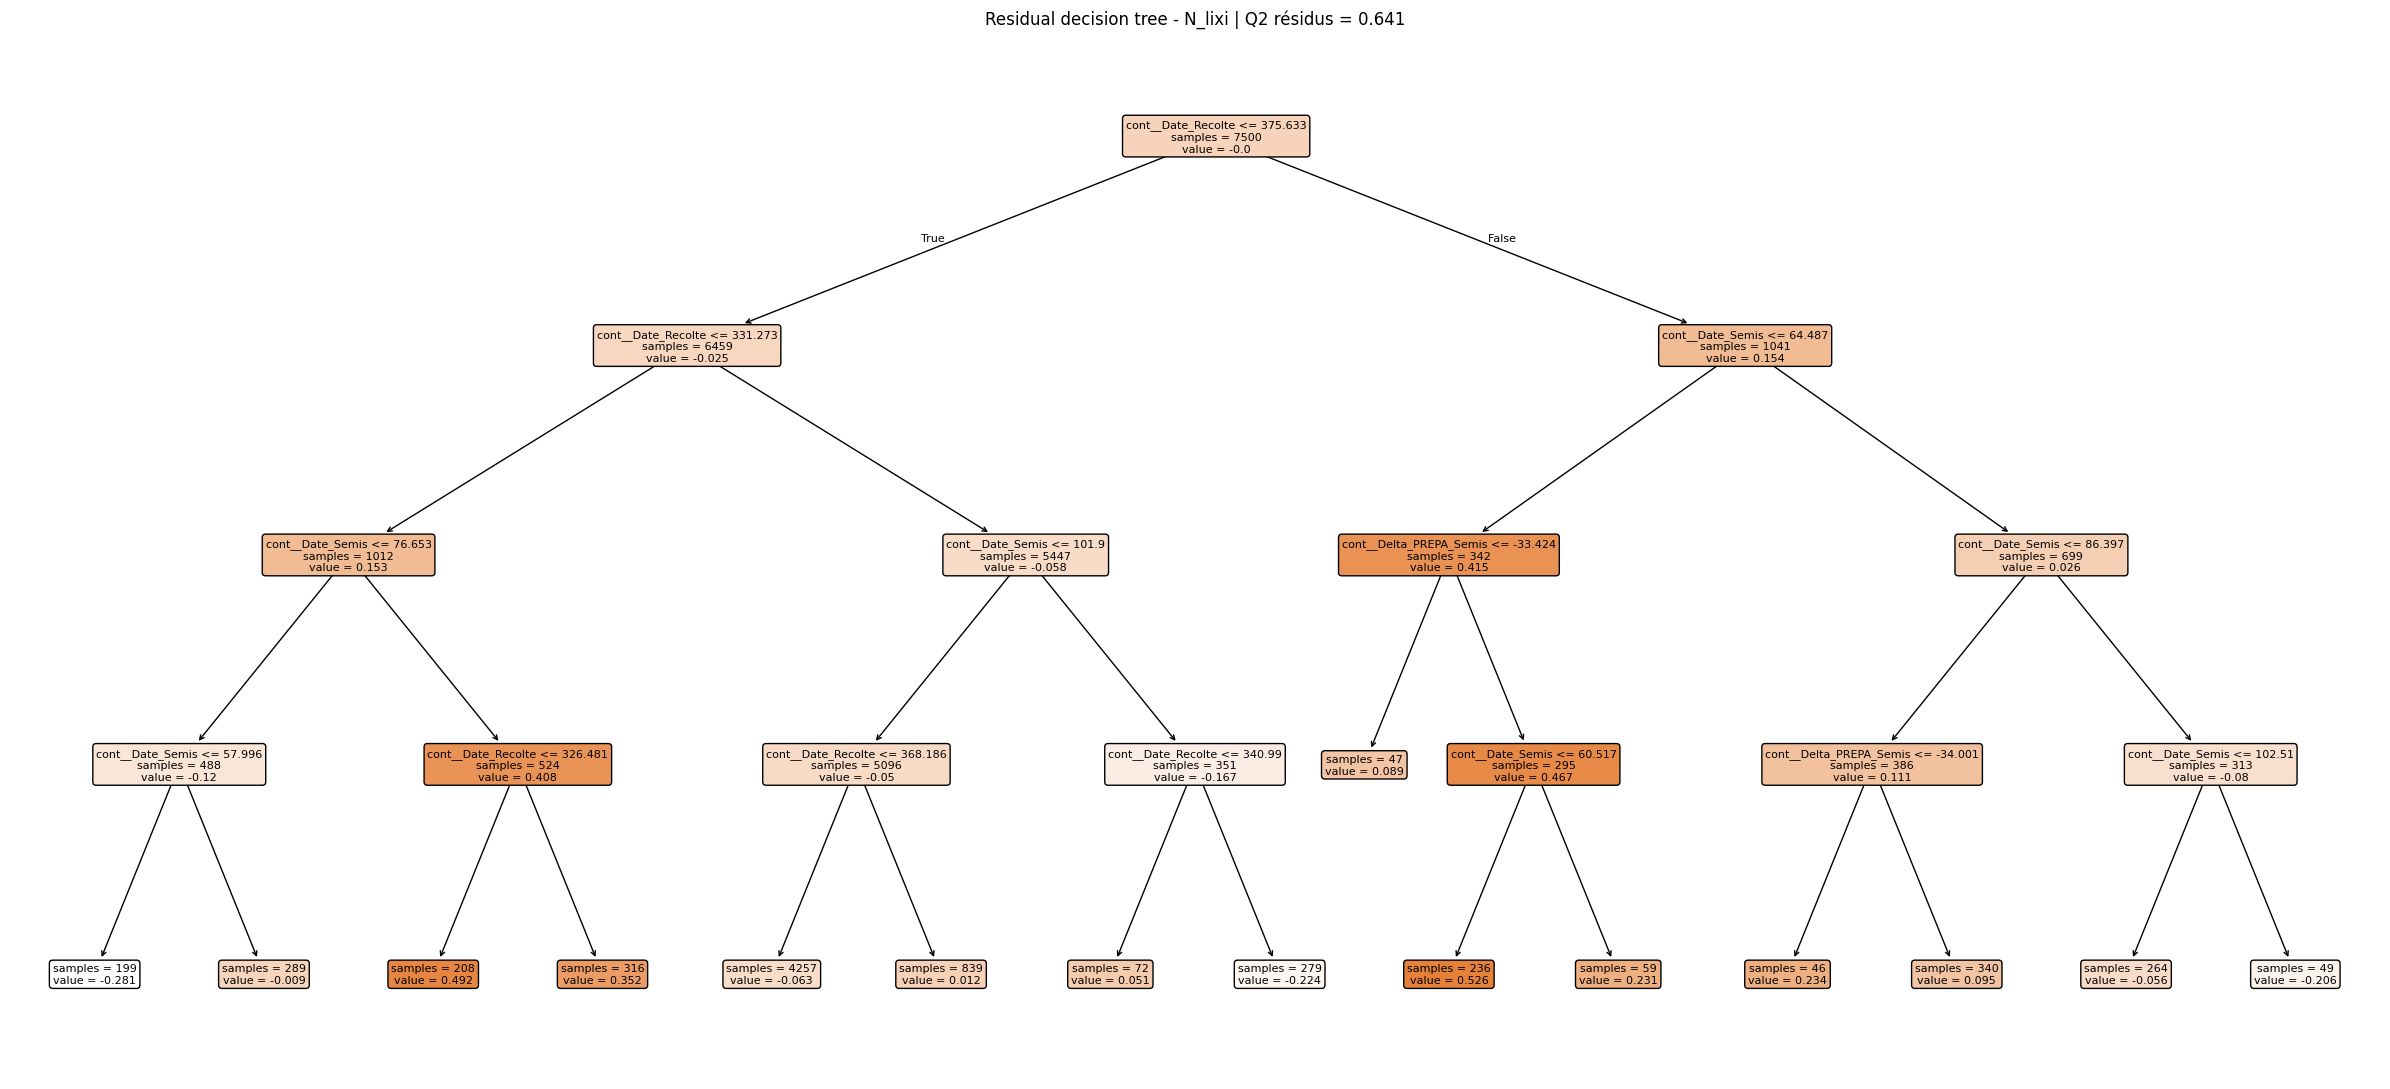


Résidus additifs - dCorg


,sortie,best_params,additive_Q2_test,residual_tree_Q2_test,residual_tree_MAE_test,residual_tree_RMSE_test
0,dCorg,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 4,...",0.9852,0.771885,1.604652,2.090144


,sortie,node,raw_feature,kind,category,threshold,left_rule,right_rule,n_node_train,n_left_train,n_right_train,mean_node_train,mean_left_train,mean_right_train,delta_right_minus_left,impurity_decrease
1,dCorg,1,Date_Recolte,continuous,None,336.655197,Date_Recolte <= 336.7,Date_Recolte > 336.7,1171,240,931,-4.786781e+00,1.000118,-6.278570,-7.278688,8.632833
7,dCorg,13,Delta_PREPA_Semis,continuous,None,-35.560158,Delta_PREPA_Semis <= -35.56,Delta_PREPA_Semis > -35.56,343,37,306,-8.372502e+00,-1.769746,-9.170874,-7.401128,5.271458
12,dCorg,24,Date_Recolte,continuous,None,351.287064,Date_Recolte <= 351.3,Date_Recolte > 351.3,1564,753,811,-2.877800e+00,-5.185672,-0.734979,4.450694,4.945358
8,dCorg,16,Date_Semis,continuous,None,93.047050,Date_Semis <= 93.05,Date_Semis > 93.05,6329,4765,1564,8.856566e-01,2.120923,-2.877800,-4.998723,4.648873
0,dCorg,0,Date_Semis,continuous,None,54.507006,Date_Semis <= 54.51,Date_Semis > 54.51,7500,1171,6329,-2.354606e-13,-4.786781,0.885657,5.672438,4.239444
11,dCorg,21,Date_Recolte,continuous,None,350.835312,Date_Recolte <= 350.8,Date_Recolte > 350.8,1658,760,898,9.169310e-01,-0.917260,2.469253,3.386514,2.847256
5,dCorg,9,Date_Recolte,continuous,None,366.591278,Date_Recolte <= 366.6,Date_Recolte > 366.6,931,588,343,-6.278570e+00,-5.057110,-8.372502,-3.315392,2.557654
6,dCorg,10,Date_Semis,continuous,None,49.569397,Date_Semis <= 49.57,Date_Semis > 49.57,588,291,297,-5.057110e+00,-6.515958,-3.627734,2.888224,2.085242
10,dCorg,18,Date_Semis,continuous,None,60.507471,Date_Semis <= 60.51,Date_Semis > 60.51,3107,742,2365,2.763414e+00,0.326562,3.527957,3.201396,1.863079
13,dCorg,25,Date_Recolte,continuous,None,330.590347,Date_Recolte <= 330.6,Date_Recolte > 330.6,753,209,544,-5.185672e+00,-7.305409,-4.371288,2.934121,1.726280


SAVE_FIGURES=False : figure non sauvegardée.


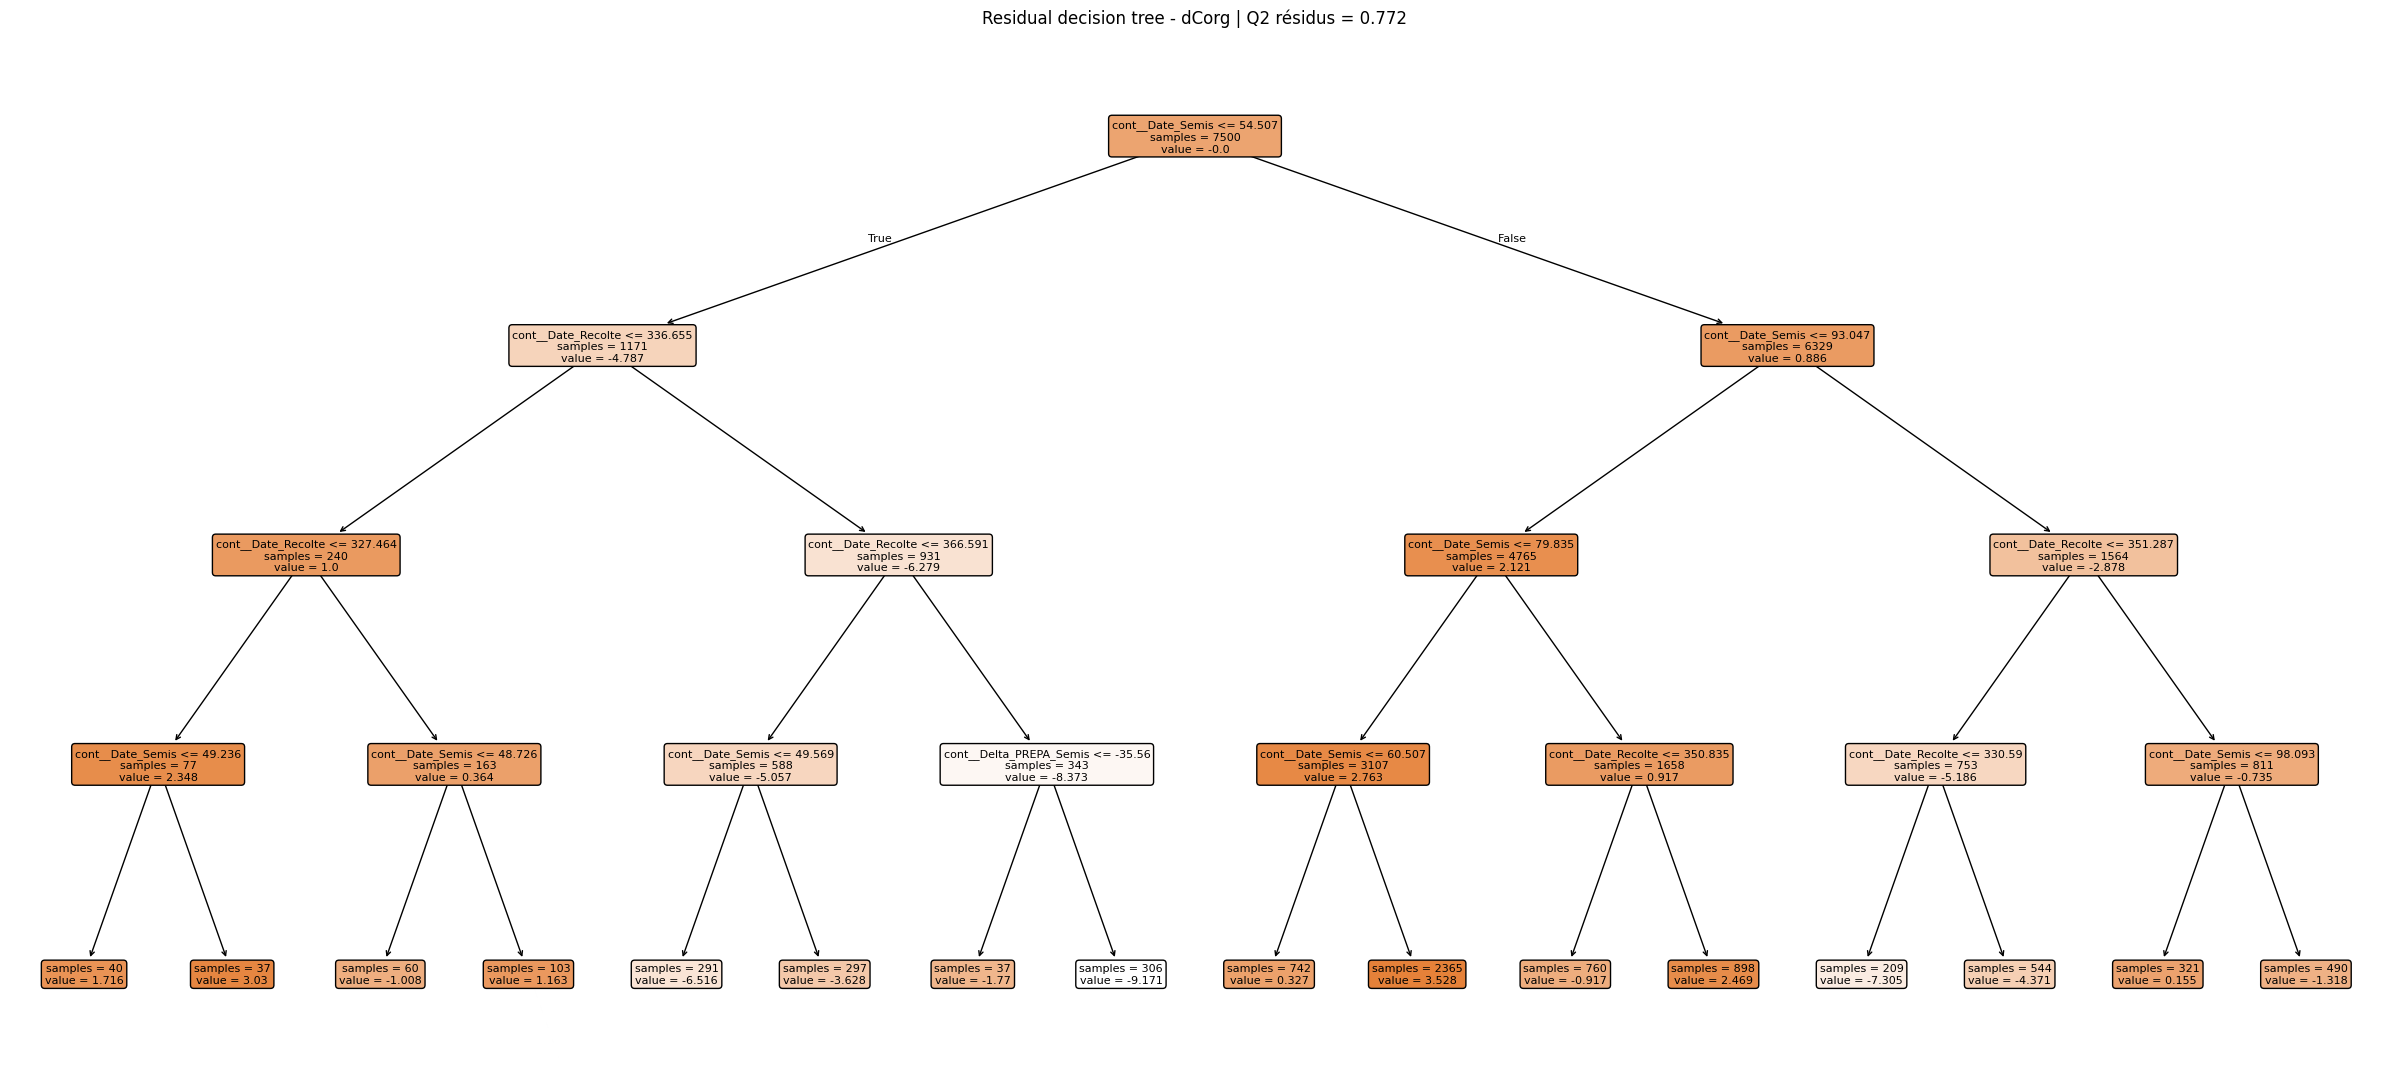


Résidus additifs - rdt


,sortie,best_params,additive_Q2_test,residual_tree_Q2_test,residual_tree_MAE_test,residual_tree_RMSE_test
0,rdt,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 4,...",0.583275,0.770942,0.032855,0.042005


,sortie,node,raw_feature,kind,category,threshold,left_rule,right_rule,n_node_train,n_left_train,n_right_train,mean_node_train,mean_left_train,mean_right_train,delta_right_minus_left,impurity_decrease
1,rdt,1,Date_Semis,continuous,None,70.552021,Date_Semis <= 70.55,Date_Semis > 70.55,1012,394,618,-8.796125e-02,0.051251,-0.176715,-0.227965,0.012356
10,rdt,18,Date_Semis,continuous,None,77.492065,Date_Semis <= 77.49,Date_Semis > 77.49,471,252,219,-1.417038e-02,0.060928,-0.100585,-0.161514,0.006490
12,rdt,24,Date_Semis,continuous,None,67.723770,Date_Semis <= 67.72,Date_Semis > 67.72,1676,637,1039,-4.353994e-02,-0.114739,0.000111,0.114850,0.003108
5,rdt,9,Date_Semis,continuous,None,81.530289,Date_Semis <= 81.53,Date_Semis > 81.53,618,181,437,-1.767146e-01,-0.105794,-0.206089,-0.100296,0.002083
2,rdt,2,Date_Semis,continuous,None,64.506508,Date_Semis <= 64.51,Date_Semis > 64.51,394,300,94,5.125081e-02,0.073243,-0.018938,-0.092181,0.001544
0,rdt,0,Date_Recolte,continuous,None,331.272598,Date_Recolte <= 331.3,Date_Recolte > 331.3,7500,1012,6488,3.510081e-16,-0.087961,0.013720,0.101681,0.001207
8,rdt,16,Date_Recolte,continuous,None,370.359375,Date_Recolte <= 370.4,Date_Recolte > 370.4,6488,4812,1676,1.372022e-02,0.033664,-0.043540,-0.077204,0.001142
6,rdt,10,Date_Recolte,continuous,None,328.549973,Date_Recolte <= 328.5,Date_Recolte > 328.5,181,114,67,-1.057935e-01,-0.129973,-0.064652,0.065321,0.000995
4,rdt,6,Date_Recolte,continuous,None,327.320129,Date_Recolte <= 327.3,Date_Recolte > 327.3,94,57,37,-1.893788e-02,-0.043152,0.018365,0.061517,0.000903
14,rdt,28,Date_Semis,continuous,None,82.468025,Date_Semis <= 82.47,Date_Semis > 82.47,1039,401,638,1.114321e-04,-0.033850,0.021457,0.055307,0.000725


SAVE_FIGURES=False : figure non sauvegardée.


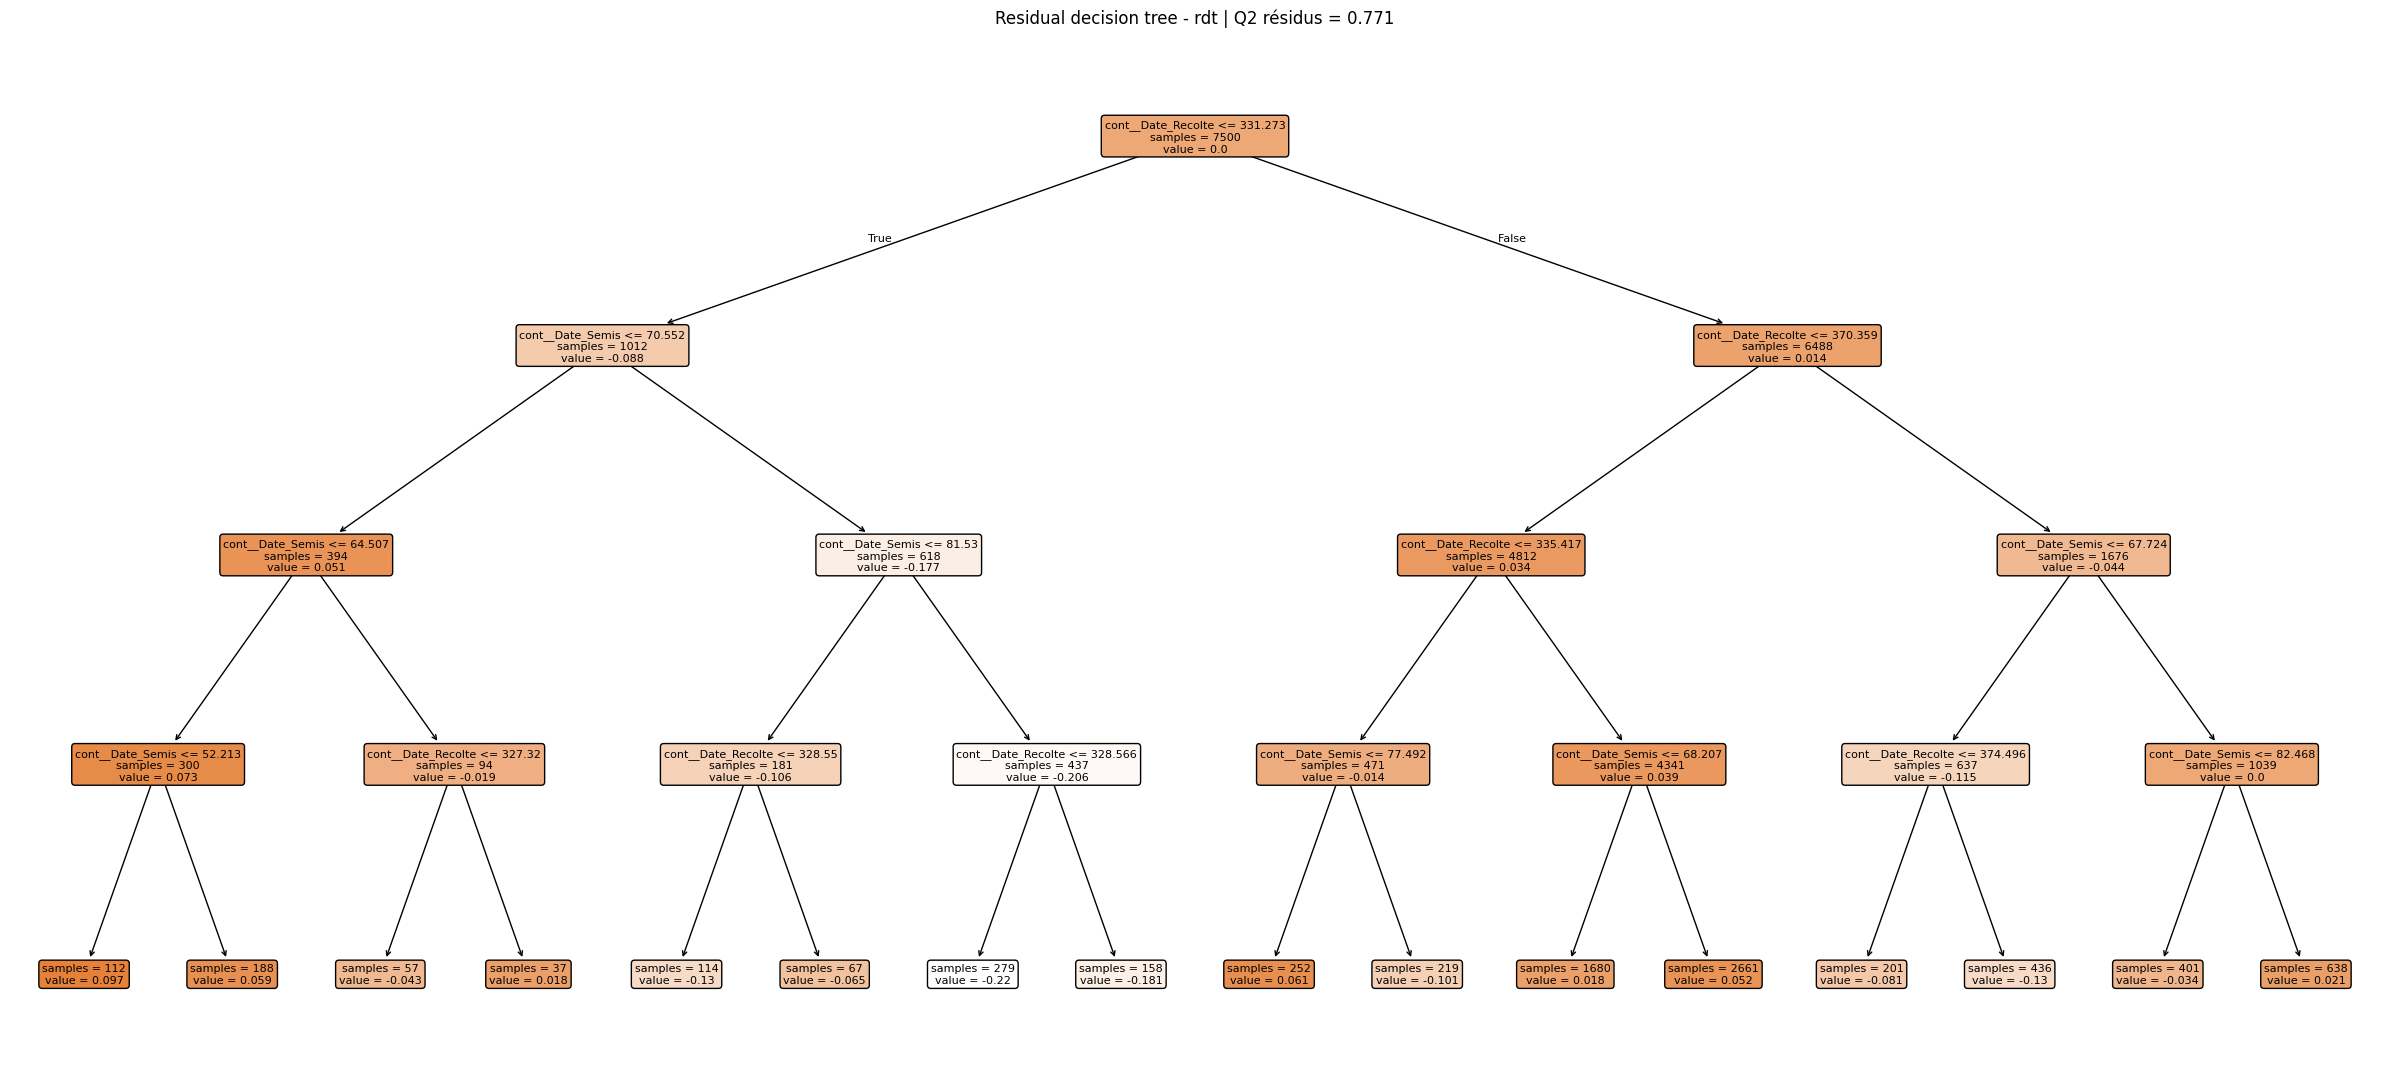

Résultats résiduels écrits dans : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/decision_tree_thresholds


,sortie,best_params,additive_Q2_test,residual_tree_Q2_test,residual_tree_MAE_test,residual_tree_RMSE_test
0,N_lixi,"{'tree__ccp_alpha': 1e-05, 'tree__max_depth': ...",0.747870,0.640974,0.099740,0.134097
1,dCorg,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 4,...",0.985200,0.771885,1.604652,2.090144
2,rdt,"{'tree__ccp_alpha': 0.0, 'tree__max_depth': 4,...",0.583275,0.770942,0.032855,0.042005


In [28]:
# ============================================================
# 8. Option : Decision tree sur résidus d'un modèle additif Ridge
# ============================================================

RUN_RESIDUAL_TREES = True

if RUN_RESIDUAL_TREES:
    residual_metrics = []
    residual_split_tables = []

    for target in OUTPUT_COLS:
        print("\n" + "=" * 80)
        print("Résidus additifs -", target)
        print("=" * 80)

        y = df[target].astype(float)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
        )

        additive = Pipeline([
            ("preprocess", build_preprocessor()),
            ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ])
        additive.fit(X_train, y_train)
        resid_train = y_train - additive.predict(X_train)
        resid_test = y_test - additive.predict(X_test)

        n_train = len(X_train)
        min_leaf_candidates = sorted({
            max(10, int(0.005 * n_train)),
            max(25, int(0.01 * n_train)),
            max(50, int(0.02 * n_train)),
            max(100, int(0.05 * n_train)),
        })

        resid_pipe = Pipeline([
            ("preprocess", build_preprocessor()),
            ("tree", DecisionTreeRegressor(random_state=RANDOM_SEED)),
        ])
        param_grid = {
            "tree__max_depth": [2, 3, 4],
            "tree__min_samples_leaf": min_leaf_candidates,
            "tree__ccp_alpha": CCP_ALPHA_CANDIDATES,
        }
        cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
        grid = GridSearchCV(resid_pipe, param_grid, scoring="r2", cv=cv, n_jobs=-1, refit=True)
        grid.fit(X_train, resid_train)
        best_resid_pipe = grid.best_estimator_

        pred_resid_test = best_resid_pipe.predict(X_test)
        metrics = {
            "sortie": target,
            "best_params": str(grid.best_params_),
            "additive_Q2_test": float(r2_score(y_test, additive.predict(X_test))),
            "residual_tree_Q2_test": float(r2_score(resid_test, pred_resid_test)),
            "residual_tree_MAE_test": float(mean_absolute_error(resid_test, pred_resid_test)),
            "residual_tree_RMSE_test": rmse(resid_test, pred_resid_test),
        }
        residual_metrics.append(metrics)
        display(pd.DataFrame([metrics]))

        preprocess = best_resid_pipe.named_steps["preprocess"]
        tree = best_resid_pipe.named_steps["tree"]
        feature_names = transformed_feature_names(preprocess)
        splits = extract_splits(tree, feature_names)
        if not splits.empty:
            splits.insert(0, "sortie", target)
            residual_split_tables.append(splits)
            splits.to_csv(OUTPUT_DIR / f"residual_tree_splits_{target}.csv", index=False)
            display(splits.head(TOP_SPLITS_TO_DISPLAY))

        plt.figure(figsize=(24, max(8, 2.2 * (tree.get_depth() + 1))))
        plot_tree(
            tree,
            feature_names=feature_names,
            filled=True,
            rounded=True,
            impurity=False,
            max_depth=PLOT_MAX_DEPTH,
            fontsize=8,
        )
        plt.title(f"Residual decision tree - {target} | Q2 résidus = {metrics['residual_tree_Q2_test']:.3f}")
        plt.tight_layout()
        save_current_figure(f"residual_decision_tree_{target}.png", f"Arbre sur résidus - {target}", target=target, kind="residual_decision_tree")
        plt.show()

    residual_metrics_df = pd.DataFrame(residual_metrics)
    residual_metrics_df.to_csv(OUTPUT_DIR / "residual_decision_tree_metrics.csv", index=False)
    if residual_split_tables:
        pd.concat(residual_split_tables, ignore_index=True).to_csv(
            OUTPUT_DIR / "residual_decision_tree_splits_all_outputs.csv", index=False
        )

    print("Résultats résiduels écrits dans :", OUTPUT_DIR)
    display(residual_metrics_df)
else:
    print("RUN_RESIDUAL_TREES=False : section ignorée.")

## Manifeste des figures

Quand `SAVE_FIGURES=True`, cette section écrit une table récapitulative des figures générées. Elle peut être utilisée directement pour mettre à jour le README.


In [29]:
# ============================================================
# 9. Manifeste des figures générées
# ============================================================

if SAVE_FIGURES and SAVED_FIGURES:
    figure_manifest = pd.DataFrame(SAVED_FIGURES).drop_duplicates()
    figure_manifest_path = OUTPUT_DIR / "figure_manifest.csv"
    figure_manifest.to_csv(figure_manifest_path, index=False)
    print("Manifeste des figures écrit :", figure_manifest_path)
    display(figure_manifest)
elif SAVE_FIGURES:
    print("Aucune figure enregistrée dans SAVED_FIGURES pour cette exécution.")
else:
    print("SAVE_FIGURES=False : aucun manifeste de figures écrit.")


SAVE_FIGURES=False : aucun manifeste de figures écrit.


## Comment lire les résultats

Une règle de type `Jour_Semis <= 31` s'interprète comme un seuil numérique : les observations situées de part et d'autre appartiennent à deux régimes prédictifs différents.

Une règle de type `n_ferti == 2.0` s'interprète comme un embranchement catégoriel : l'arbre a isolé cette modalité parce qu'elle modifie localement la réponse.

Les seuils doivent être lus localement, dans le contexte des règles parentes. Par exemple, un seuil de fertilisation situé sous une branche déjà conditionnée par une date de semis ne signifie pas forcément que ce seuil est globalement valable sur tout le domaine.